# Fine-Tuning vs Feature Extraction: A Study of Low-Resource Adaptation for Scientific QA

**Course:** COMP 6841 — Applied Deep Learning

**Name:** Ahmad Hasan

 **Student ID:** 40294488

**Dataset:** SciQ (Allen Institute for AI)
  
**Backbone:** DistilGPT-2 (~82M parameters)  

---

## Abstract

This project investigates two domain adaptation strategies for small pre-trained language models applied to scientific question answering under strict computational constraints. The first approach is parameter-efficient fine-tuning using Low-Rank Adaptation (LoRA), which updates a small set of auxiliary parameters while the backbone remains largely intact. The second approach is feature-based transfer learning, where the backbone is fully frozen and only a lightweight task-specific head is trained. Both methods are evaluated on the SciQ dataset using Exact Match, Token F1, and Perplexity as primary metrics, with training time and parameter efficiency recorded as secondary efficiency metrics.

---

## Table of Contents

1. Environment Setup  
2. Dataset: SciQ  
3. Data Preprocessing and Engineering  
4. Tokenization and Dataset Construction  
5. **Experiment 1 — Baseline: LoRA Fine-Tuning (Conservative Configuration)**  
   - 5.1 Model Configuration  
   - 5.2 Training  
   - 5.3 Evaluation and Reflection  
6. **Experiment 2 — Improved LoRA (Informed by Baseline)**  
   - 6.1 Changes and Rationale  
   - 6.2 Training  
   - 6.3 Evaluation: Decoding Bug and Fix  
   - 6.4 Final Results  
7. **Experiment 3 — Feature Extraction: Frozen Backbone + MLP Head**
8. Comparison and Analysis

---
## 1. Environment Setup

All experiments were run on Google Colab with a Tesla T4 GPU (15.6 GB VRAM, ~13.6 GB RAM). The cell below installs required packages and performs a resource check before any training begins.

In [ ]:
!pip install -q transformers datasets peft accelerate scikit-learn evaluate

import torch
import gc
import os
import psutil


def memory_report() -> None:
    """Print current RAM and GPU VRAM usage.

    Reports system RAM utilization and, when a CUDA device is available,
    the reserved VRAM and GPU model name. Useful for confirming headroom
    before and after memory-intensive operations.

    Arguments:
        None

    Returns:
        None — prints to stdout.

    Example:
        >>> memory_report()
        RAM  : 5.4 GB used / 13.6 GB total
        VRAM : 2.2 GB reserved / 15.6 GB total
        GPU  : Tesla T4
    """
    ram = psutil.virtual_memory()
    print(f"RAM  : {ram.used / 1e9:.1f} GB used / {ram.total / 1e9:.1f} GB total")
    if torch.cuda.is_available():
        vram = torch.cuda.memory_reserved(0)
        total = torch.cuda.get_device_properties(0).total_memory
        print(f"VRAM : {vram / 1e9:.1f} GB reserved / {total / 1e9:.1f} GB total")
        print(f"GPU  : {torch.cuda.get_device_name(0)}")
    else:
        print("GPU  : not available (CPU mode)")


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
memory_report()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00
Device: cuda
RAM  : 2.1 GB used / 13.6 GB total
VRAM : 0.0 GB reserved / 15.6 GB total
GPU  : Tesla T4


---
## 2. Dataset: SciQ

SciQ (Welbl et al., 2017) is a multiple-choice science question answering dataset collected from science exams covering physics, chemistry, biology, and earth science. Each sample contains a question, four candidate answers (one correct, three distractors), and a short explanatory passage called `support`.

For this project the task is reformulated as **extractive generative QA**: given the support passage as context and the question as a prompt, the model must generate the correct answer string. The distractor fields are discarded. This formulation is more realistic and more challenging than multiple-choice classification, and it allows for a direct comparison of generation quality between the two adaptation strategies.

The dataset is split into official train / validation / test partitions, which are used as-is to prevent any data leakage.

In [ ]:
from datasets import load_dataset

print("Loading SciQ from HuggingFace hub...")
raw_dataset = load_dataset("allenai/sciq")

print("\nOfficial split sizes:")
for split, ds in raw_dataset.items():
    print(f"  {split:<12}: {len(ds):>6,} samples")

# Inspecting one example to understand field structure
print("\nRaw example (train[0]):")
example = raw_dataset["train"][0]
for key, value in example.items():
    print(f"  [{key}] {str(value)[:110]}")

Loading SciQ from HuggingFace hub...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.99M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/339k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/343k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11679 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]


Official split sizes:
  train       : 11,679 samples
  validation  :  1,000 samples
  test        :  1,000 samples

Raw example (train[0]):
  [question] What type of organism is commonly used in preparation of foods such as cheese and yogurt?
  [distractor3] viruses
  [distractor1] protozoa
  [distractor2] gymnosperms
  [correct_answer] mesophilic organisms
  [support] Mesophiles grow best in moderate temperature, typically between 25°C and 40°C (77°F and 104°F). Mesophiles are


---
## 3. Data Preprocessing and Engineering

The preprocessing pipeline performs the following steps:

**Cleaning.** Whitespace is normalised and non-ASCII characters are removed. Samples with empty context, question, or answer fields are discarded, as are answers shorter than two characters.

**Context clipping.** Support passages longer than `MAX_CONTEXT_WORDS` words are truncated. This bound is set conservatively at first and revised in Experiment 2 after inspecting the actual token length distribution.

**Prompt construction.** Each sample is formatted into a single string using a fixed template:
```
Context: <support>\nQuestion: <question>\nAnswer: <correct_answer><|endoftext|>
```
A separate inference-time template omits the answer and EOS token:
```
Context: <support>\nQuestion: <question>\nAnswer:
```
This design is compatible with GPT-2's causal language modelling objective and allows the training loss to be computed only over answer tokens (via label masking), not over the prompt prefix.

In [ ]:
import re
import pandas as pd

TRAIN_TEMPLATE = "Context: {context}\nQuestion: {question}\nAnswer: {answer}<|endoftext|>"
INFER_TEMPLATE = "Context: {context}\nQuestion: {question}\nAnswer:"


def clean_text(text: str) -> str:
    """Normalise whitespace and remove non-ASCII characters from a string.

    Arguments:
        text (str): Raw input string.

    Returns:
        str: Cleaned string with collapsed whitespace and ASCII characters only.

    Example:
        >>> clean_text("  Hello\u00a0world  ")
        'Hello world'
    """
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    return text


def clip_words(text: str, max_words: int) -> str:
    """Truncate a string to at most max_words whitespace-delimited tokens.

    Arguments:
        text (str): Input string.
        max_words (int): Maximum number of words to retain.

    Returns:
        str: Truncated string.

    Example:
        >>> clip_words("one two three four", 3)
        'one two three'
    """
    return " ".join(text.split()[:max_words])


def process_split(
    hf_split,
    max_context_words: int,
    min_answer_chars: int = 2,
    cap: int = None,
) -> pd.DataFrame:
    """Convert a raw SciQ HuggingFace split into a cleaned DataFrame.

    Applies text cleaning, quality filters, context clipping, and prompt
    construction. Returns a DataFrame with one row per valid sample.

    Arguments:
        hf_split: A HuggingFace Dataset split (iterable of dicts with keys
            'support', 'question', 'correct_answer').
        max_context_words (int): Maximum number of words retained from the
            support passage.
        min_answer_chars (int): Minimum character length for a valid answer.
            Defaults to 2.
        cap (int or None): Maximum number of rows to return. None uses all
            available samples.

    Returns:
        pd.DataFrame: DataFrame with columns ['context', 'question', 'answer',
            'prompt_train', 'prompt_infer'].

    Example:
        >>> df = process_split(raw_dataset["train"], max_context_words=150)
        >>> df.columns.tolist()
        ['context', 'question', 'answer', 'prompt_train', 'prompt_infer']
    """
    rows = []
    for item in hf_split:
        ctx = clean_text(item["support"])
        q = clean_text(item["question"])
        a = clean_text(item["correct_answer"])

        # Quality filters: discard incomplete or trivially short samples
        if not ctx or not q or not a:
            continue
        if len(a) < min_answer_chars:
            continue
        if len(ctx.split()) < 5:
            continue

        ctx = clip_words(ctx, max_context_words)

        rows.append({
            "context": ctx,
            "question": q,
            "answer": a,
            "prompt_train": TRAIN_TEMPLATE.format(context=ctx, question=q, answer=a),
            "prompt_infer": INFER_TEMPLATE.format(context=ctx, question=q),
        })

        if cap is not None and len(rows) >= cap:
            break

    return pd.DataFrame(rows)


print("process_split defined.")

process_split defined.


Processing dataset splits...

Processed split sizes:
  train : 10,459
  val   : 887
  test  : 881

Gold answer length distribution (training set):
  Mean   : 1.52 words
  Median : 1 words
  p90    : 2 words
  p99    : 4 words
  Max    : 12 words


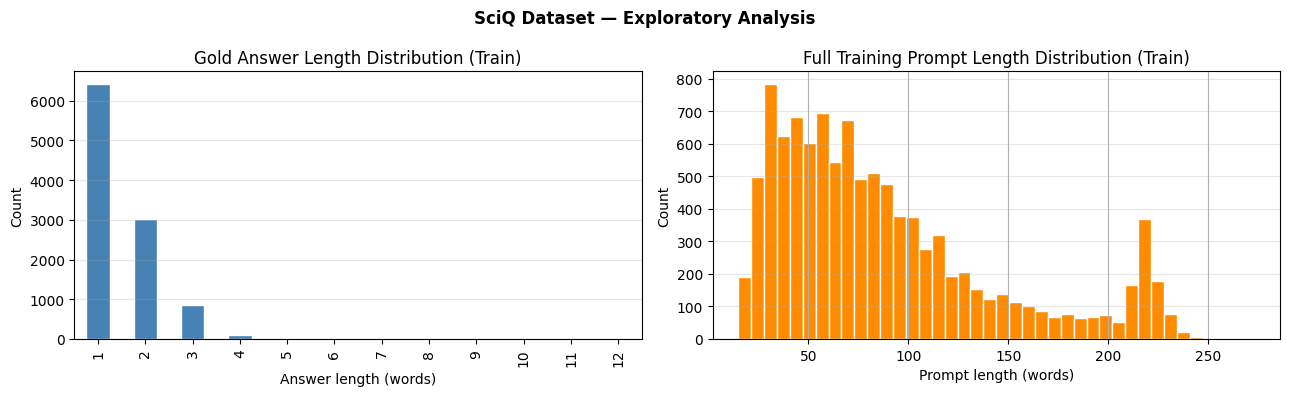

RAM  : 1.5 GB used / 13.6 GB total
VRAM : 0.0 GB reserved / 15.6 GB total
GPU  : Tesla T4


In [ ]:
import matplotlib.pyplot as plt

# MAX_CONTEXT_WORDS is set to 200 following the data-driven analysis in Section 6.1. This value is referenced here so preprocessing is consistent across experiments.
MAX_CONTEXT_WORDS = 200

print("Processing dataset splits...")
df_train = process_split(raw_dataset["train"],      max_context_words=MAX_CONTEXT_WORDS)
df_val   = process_split(raw_dataset["validation"], max_context_words=MAX_CONTEXT_WORDS)
df_test  = process_split(raw_dataset["test"],       max_context_words=MAX_CONTEXT_WORDS)

# Saving memory by cleaning up
del raw_dataset
gc.collect()

print(f"\nProcessed split sizes:")
print(f"  train : {len(df_train):,}")
print(f"  val   : {len(df_val):,}")
print(f"  test  : {len(df_test):,}")

# Exploratory analysis: gold answer length distribution. This informs the choice of max_new_tokens during decoding
answer_lengths = df_train["answer"].str.split().str.len()

print("\nGold answer length distribution (training set):")
print(f"  Mean   : {answer_lengths.mean():.2f} words")
print(f"  Median : {answer_lengths.median():.0f} words")
print(f"  p90    : {answer_lengths.quantile(0.90):.0f} words")
print(f"  p99    : {answer_lengths.quantile(0.99):.0f} words")
print(f"  Max    : {answer_lengths.max()} words")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

answer_lengths.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_xlabel("Answer length (words)")
axes[0].set_ylabel("Count")
axes[0].set_title("Gold Answer Length Distribution (Train)")
axes[0].grid(axis="y", alpha=0.3)

df_train["prompt_train"].str.split().str.len().hist(
    bins=40, ax=axes[1], color="darkorange", edgecolor="white"
)
axes[1].set_xlabel("Prompt length (words)")
axes[1].set_ylabel("Count")
axes[1].set_title("Full Training Prompt Length Distribution (Train)")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("SciQ Dataset — Exploratory Analysis", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("sciq_eda.png", dpi=110)
plt.show()

memory_report()

---
## 4. Tokenization and Dataset Construction

All experiments share the same tokenizer (DistilGPT-2) and the same `SciQDataset` class. The class is defined once here and reused without modification.

**Label masking.** The model is trained with a causal language modelling loss. To prevent the loss from being computed over the context and question prefix, all token positions belonging to the prompt prefix are masked to `-100` in the labels tensor. The loss is therefore computed only over the answer tokens, which is found to be standard for instruction-following and QA fine-tuning with GPT-style models.

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# GPT-2 has no padding token by default, hence setting eos as pad
# for causal LM fine-tuning; the padding positions are masked in labels anyway.
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"  # left-pad for autoregressive generation

print(f"Tokenizer: {MODEL_NAME}")
print(f"Vocabulary size : {tokenizer.vocab_size:,}")
print(f"Pad token       : {tokenizer.pad_token!r} (id={tokenizer.pad_token_id})")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: distilgpt2
Vocabulary size : 50,257
Pad token       : '<|endoftext|>' (id=50256)


In [ ]:
from torch.utils.data import Dataset


class SciQDataset(Dataset):
    """PyTorch Dataset for causal language model fine-tuning on SciQ.

    Each item contains a tokenized prompt (context + question + answer) with
    labels masked to -100 over the prompt prefix, so the training loss is
    computed only over answer tokens. The raw answer string and inference
    prompt are also returned for use during evaluation.

    Arguments:
        df (pd.DataFrame): Preprocessed DataFrame with columns ['prompt_train',
            'prompt_infer', 'answer'].
        tokenizer: A HuggingFace tokenizer compatible with the target model.
        max_length (int): Maximum sequence length in tokens. Sequences are
            padded or truncated to this length.

    Returns (per item):
        dict with keys:
            'input_ids'      (torch.Tensor, shape [max_length])
            'attention_mask' (torch.Tensor, shape [max_length])
            'labels'         (torch.Tensor, shape [max_length]) — -100 on prefix and padding
            'answer'         (str) — gold answer string for evaluation
            'prompt_infer'   (str) — inference-time prompt for generation

    Example:
        >>> ds = SciQDataset(df_train, tokenizer, max_length=256)
        >>> item = ds[0]
        >>> item['input_ids'].shape
        torch.Size([256])
    """

    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int):
        self.data = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> dict:
        row = self.data.iloc[idx]

        # Tokenize full training prompt (context, question, answer, EOS)
        enc = self.tokenizer(
            row["prompt_train"],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        # Tokenizing only the inference prefix to determine where the answer begins.
        prefix_len = len(self.tokenizer(
            row["prompt_infer"],
            truncation=True,
            max_length=self.max_length,
        )["input_ids"])

        input_ids = enc["input_ids"].squeeze()
        attention_mask = enc["attention_mask"].squeeze()

        # masking padding and the prompt prefix with -100.
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100  # mask all padding positions

        num_real = attention_mask.sum().item()
        answer_start = self.max_length - num_real + prefix_len
        if answer_start > 0:
            labels[:answer_start] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "answer": row["answer"],
            "prompt_infer": row["prompt_infer"],
        }


def collate_fn(batch: list) -> dict:
    """Collate a list of SciQDataset items into a batched dictionary.

    Stacks tensor fields and collects string fields as lists, allowing the
    Trainer to receive both tensor inputs for loss computation and string
    fields for evaluation.

    Arguments:
        batch (list of dict): List of items returned by SciQDataset.__getitem__.

    Returns:
        dict with keys 'input_ids', 'attention_mask', 'labels' (tensors),
        'answer' and 'prompt_infer' (lists of str).

    Example:
        >>> loader = DataLoader(ds, batch_size=4, collate_fn=collate_fn)
        >>> batch = next(iter(loader))
        >>> batch['input_ids'].shape
        torch.Size([4, 256])
    """
    return {
        "input_ids":      torch.stack([b["input_ids"]      for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
        "labels":         torch.stack([b["labels"]         for b in batch]),
        "answer":         [b["answer"]       for b in batch],
        "prompt_infer":   [b["prompt_infer"] for b in batch],
    }


print("SciQDataset and collate_fn defined.")

SciQDataset and collate_fn defined.


---
## 5. Experiment 1 — Baseline: LoRA Fine-Tuning

The first experiment establishes a baseline using conservative hyperparameters chosen to stay well within Colab's resource limits. The goal is not to maximise performance but to verify the training pipeline, establish reference metrics, and identify where additional resources can be safely allocated in a second run.

### 5.1 Model Configuration

**Backbone.** DistilGPT-2 is a distilled version of GPT-2 with 6 transformer layers and approximately 82 million parameters. It was chosen because it is small enough to train on a free Colab T4 while still providing meaningful pre-trained representations of English text.

**LoRA.** Low-Rank Adaptation (Hu et al., 2022) adds a pair of low-rank matrices to each target linear layer. Only these auxiliary matrices are updated during training; the original weights remain frozen. This reduces the number of trainable parameters from 82M to approximately 238K, drastically lowering memory and compute requirements.

The baseline targets only the attention projection layers (`c_attn`, `c_proj`) with rank `r=8`.

In [ ]:
# Baseline configuration
BASELINE_CONFIG = {
    "max_length":    256,
    "train_cap":     8_000,
    "val_cap":       1_000,
    "test_cap":      500,
    "lora_r":        8,
    "lora_alpha":    16,
    "lora_dropout":  0.1,
    "lora_targets":  ["c_attn", "c_proj"],
    "epochs":        3,
    "batch_size":    4,
    "grad_accum":    8,
    "lr":            3e-4,
    "max_new_tokens": 30,
}

for k, v in BASELINE_CONFIG.items():
    print(f"  {k:<20}: {v}")

  max_length          : 256
  train_cap           : 8000
  val_cap             : 1000
  test_cap            : 500
  lora_r              : 8
  lora_alpha          : 16
  lora_dropout        : 0.1
  lora_targets        : ['c_attn', 'c_proj']
  epochs              : 3
  batch_size          : 4
  grad_accum          : 8
  lr                  : 0.0003
  max_new_tokens      : 30


In [ ]:
# Building baseline datasets using capped splits.
train_ds_v1 = SciQDataset(
    df_train.iloc[:BASELINE_CONFIG["train_cap"]].reset_index(drop=True),
    tokenizer,
    BASELINE_CONFIG["max_length"],
)
val_ds_v1 = SciQDataset(
    df_val.iloc[:BASELINE_CONFIG["val_cap"]].reset_index(drop=True),
    tokenizer,
    BASELINE_CONFIG["max_length"],
)
test_ds_v1 = SciQDataset(
    df_test.iloc[:BASELINE_CONFIG["test_cap"]].reset_index(drop=True),
    tokenizer,
    BASELINE_CONFIG["max_length"],
)

print(f"Baseline dataset sizes:")
print(f"  train : {len(train_ds_v1):,}")
print(f"  val   : {len(val_ds_v1):,}")
print(f"  test  : {len(test_ds_v1):,}")

# Verifying label masking: count answer tokens in one sample.
sample = train_ds_v1[0]
n_answer_tokens = (sample["labels"] != -100).sum().item()
print(f"\nSample check: {n_answer_tokens} answer tokens supervised out of "
      f"{BASELINE_CONFIG['max_length']} total positions")
print(f"Gold answer: {sample['answer']}")

Baseline dataset sizes:
  train : 8,000
  val   : 887
  test  : 500

Sample check: 5 answer tokens supervised out of 256 total positions
Gold answer: mesophilic organisms


In [ ]:
from transformers import AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType


def build_lora_model(
    model_name: str,
    tokenizer,
    lora_r: int,
    lora_alpha: int,
    lora_dropout: float,
    target_modules: list,
    device: torch.device,
):
    """Load a causal LM backbone and attach a LoRA adapter.

    Loads the specified pre-trained model in fp16 (when a GPU is available),
    resizes token embeddings to match the tokenizer vocabulary, and wraps
    the model with a PEFT LoRA configuration.

    Arguments:
        model_name (str): HuggingFace model identifier.
        tokenizer: Tokenizer instance (used to resize embeddings).
        lora_r (int): LoRA rank.
        lora_alpha (int): LoRA scaling factor.
        lora_dropout (float): Dropout rate applied to LoRA layers.
        target_modules (list of str): Names of linear layers to adapt.
        device (torch.device): Device to move the model to.

    Returns:
        PeftModel: The backbone with LoRA adapters attached and moved to device.

    Example:
        >>> model = build_lora_model(
        ...     "distilgpt2", tokenizer, lora_r=8, lora_alpha=16,
        ...     lora_dropout=0.1, target_modules=["c_attn"], device=DEVICE
        ... )
    """
    base = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    )
    base.resize_token_embeddings(len(tokenizer))

    config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=lora_r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        bias="none",
        target_modules=target_modules,
    )
    model = get_peft_model(base, config)
    model.to(device)
    return model


print("Building baseline LoRA model...")
model_v1 = build_lora_model(
    MODEL_NAME, tokenizer,
    lora_r=BASELINE_CONFIG["lora_r"],
    lora_alpha=BASELINE_CONFIG["lora_alpha"],
    lora_dropout=BASELINE_CONFIG["lora_dropout"],
    target_modules=BASELINE_CONFIG["lora_targets"],
    device=DEVICE,
)
model_v1.print_trainable_parameters()
memory_report()

Building baseline LoRA model...


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 405,504 || all params: 82,318,080 || trainable%: 0.4926
RAM  : 3.5 GB used / 13.6 GB total
VRAM : 0.2 GB reserved / 15.6 GB total
GPU  : Tesla T4


### 5.2 Training — Baseline

In [ ]:
from transformers import TrainingArguments, Trainer
import time


class SciQTrainer(Trainer):
    """Trainer subclass that removes non-tensor fields before the forward pass.

    SciQDataset items include 'answer' (str) and 'prompt_infer' (str) for
    evaluation. These cannot be passed to the model's forward method and must
    be popped from the batch dict before the parent Trainer calls the model.

    Arguments:
        Inherits all arguments from transformers.Trainer.

    Returns:
        Inherits all return values from transformers.Trainer.

    Example:
        >>> trainer = SciQTrainer(model=model, args=args, ...)
        >>> trainer.train()
    """

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        inputs.pop("answer", None)
        inputs.pop("prompt_infer", None)
        return super().compute_loss(model, inputs, return_outputs=return_outputs, **kwargs)


def make_training_args(
    output_dir: str,
    epochs: int,
    batch_size: int,
    grad_accum: int,
    lr: float,
    logging_steps: int = 20,
    train_dataset_length: int = 0,  # Used for warmup_steps calculation
) -> TrainingArguments:
    """Construct a TrainingArguments object for SciQ LoRA experiments.

    Arguments:
        output_dir (str): Directory for checkpoints and logs.
        epochs (int): Number of training epochs.
        batch_size (int): Per-device training batch size.
        grad_accum (int): Gradient accumulation steps.
        lr (float): Peak learning rate.
        logging_steps (int): Log training loss every N steps. Defaults to 20.
        train_dataset_length (int): Length of the training dataset, used for warmup_steps calculation.

    Returns:
        TrainingArguments: Configured arguments object.

    Example:
        >>> args = make_training_args('./out', epochs=3, batch_size=4,
        ...                           grad_accum=8, lr=3e-4)
    """
    # Calculate total steps for warmup_steps
    total_train_steps = (train_dataset_length // (batch_size * grad_accum)) * epochs
    warmup_steps = int(total_train_steps * 0.05) # Using the original warmup_ratio of 0.05

    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        gradient_accumulation_steps=grad_accum,
        learning_rate=lr,
        lr_scheduler_type="cosine",
        warmup_steps=warmup_steps, # Changed from warmup_ratio
        weight_decay=0.01,
        fp16=torch.cuda.is_available(),
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        logging_steps=logging_steps,
        TENSORBOARD_LOGGING_DIR=f"{output_dir}/logs", # Changed from logging_dir
        report_to="none",
        dataloader_num_workers=2,
        remove_unused_columns=False,
    )


args_v1 = make_training_args(
    "./exp1_baseline",
    epochs=BASELINE_CONFIG["epochs"],
    batch_size=BASELINE_CONFIG["batch_size"],
    grad_accum=BASELINE_CONFIG["grad_accum"],
    lr=BASELINE_CONFIG["lr"],
    logging_steps=50,
    train_dataset_length=len(train_ds_v1),
)

trainer_v1 = SciQTrainer(
    model=model_v1,
    args=args_v1,
    train_dataset=train_ds_v1,
    eval_dataset=val_ds_v1,
    data_collator=collate_fn,
)

print("Training baseline model...")
t0 = time.time()
trainer_v1.train()
elapsed_v1 = time.time() - t0
print(f"\nBaseline training complete: {elapsed_v1 / 60:.1f} min")
memory_report()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training baseline model...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,1.866221,1.417482
2,1.455573,1.200615
3,1.397395,1.185216



Baseline training complete: 7.7 min
RAM  : 5.5 GB used / 13.6 GB total
VRAM : 2.2 GB reserved / 15.6 GB total
GPU  : Tesla T4


### 5.3 Evaluation and Reflection — Baseline

Evaluation uses three metrics:

- **Exact Match (EM):** 1 if the normalised predicted string equals the normalised gold answer, 0 otherwise. Normalisation lowercases text and strips punctuation.
- **Token F1:** The overlap F1 between predicted and gold token sets.
- **Perplexity:** Computed from the mean negative log-likelihood over answer tokens on the test set. Lower is better.

Greedy decoding is used for the baseline, consistent with prior work on small LMs.

In [ ]:
import math
import string
from collections import Counter
from torch.utils.data import DataLoader


def normalize_answer(text: str) -> str:
    """Lowercase and remove punctuation from a string for metric computation.

    Follows the SQuAD evaluation normalisation protocol.

    Arguments:
        text (str): Raw predicted or gold answer string.

    Returns:
        str: Lowercased, punctuation-free, whitespace-normalised string.

    Example:
        >>> normalize_answer("Highly Viscous.")
        'highly viscous'
    """
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    return re.sub(r"\s+", " ", text).strip()


def exact_match(pred: str, gold: str) -> int:
    """Compute Exact Match between a prediction and a gold answer.

    Arguments:
        pred (str): Model prediction.
        gold (str): Gold answer string.

    Returns:
        int: 1 if normalised strings match exactly, 0 otherwise.

    Example:
        >>> exact_match("Highly Viscous.", "highly viscous")
        1
    """
    return int(normalize_answer(pred) == normalize_answer(gold))


def token_f1(pred: str, gold: str) -> float:
    """Compute token-level F1 score between a prediction and a gold answer.

    Computes precision and recall over the multiset intersection of tokens,
    following the SQuAD evaluation protocol.

    Arguments:
        pred (str): Model prediction.
        gold (str): Gold answer string.

    Returns:
        float: F1 score in [0, 1]. Returns 0.0 if either sequence is empty.

    Example:
        >>> token_f1("plant hormones", "plant hormone receptors")
        0.5
    """
    p_tokens = normalize_answer(pred).split()
    g_tokens = normalize_answer(gold).split()
    if not p_tokens or not g_tokens:
        return 0.0
    common = Counter(p_tokens) & Counter(g_tokens)
    n_common = sum(common.values())
    if n_common == 0:
        return 0.0
    precision = n_common / len(p_tokens)
    recall = n_common / len(g_tokens)
    return 2 * precision * recall / (precision + recall)


def postprocess_prediction(text: str) -> str:
    """Strip over-generated content from a model prediction.

    SciQ answers are short phrases (median 1 word). This function removes
    content after newlines, prompt markers, parenthetical explanations,
    and trailing clauses introduced by commas, which are common failure modes
    of autoregressive generation on short-answer tasks.

    Arguments:
        text (str): Raw decoded model output.

    Returns:
        str: Cleaned prediction string.

    Example:
        >>> postprocess_prediction("sediments, which are deposited on the ocean floor")
        'sediments'
    """
    text = text.strip()
    # Stop at any prompt continuation markers
    for marker in ["\n", "Context:", "Question:", "Answer:"]:
        if marker in text:
            text = text[:text.index(marker)]
    # Strip parenthetical explanations: "altitude (or elevation)" -> "altitude"
    text = re.split(r"\s*[\(\[]", text)[0]
    # Strip trailing clauses after a comma if the first segment is short
    parts = text.split(",")
    if len(parts) > 1 and len(parts[0].split()) <= 5:
        text = parts[0]
    return text.strip()


def compute_perplexity(
    model,
    dataset: Dataset,
    device: torch.device,
    batch_size: int = 8,
) -> float:
    """Compute perplexity on answer tokens over a dataset.

    Perplexity is computed as exp(mean NLL) where the NLL is averaged only
    over non-masked label positions (i.e., answer tokens).

    Arguments:
        model: A HuggingFace CausalLM (or PeftModel wrapping one).
        dataset (Dataset): A SciQDataset instance with labelled samples.
        device (torch.device): Device for inference.
        batch_size (int): Batch size for the DataLoader. Defaults to 8.

    Returns:
        float: Perplexity score. Returns inf if no labelled tokens found.

    Example:
        >>> ppl = compute_perplexity(model, test_ds, DEVICE)
        >>> print(f"{ppl:.2f}")
    """
    model.eval()
    total_nll, total_tokens = 0.0, 0
    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=collate_fn)

    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labs = batch["labels"].to(device)
            out = model(input_ids=ids, attention_mask=mask, labels=labs)
            n_tok = (labs != -100).sum().item()
            total_nll += out.loss.item() * n_tok
            total_tokens += n_tok

    return math.exp(total_nll / total_tokens) if total_tokens > 0 else float("inf")


def generate_and_evaluate(
    model,
    dataset: Dataset,
    tokenizer,
    device: torch.device,
    max_length: int,
    max_new_tokens: int,
    num_beams: int = 1,
    length_penalty: float = 1.0,
    no_repeat_ngram_size: int = 0,
    batch_size: int = 8,
) -> dict:
    """Generate predictions for a dataset and compute EM and F1 scores.

    Runs batched generation over the dataset using the specified decoding
    strategy, applies postprocess_prediction to each output, and computes
    Exact Match and Token F1 against gold answers.

    Arguments:
        model: A trained causal LM or PeftModel.
        dataset (Dataset): A SciQDataset instance.
        tokenizer: HuggingFace tokenizer.
        device (torch.device): Device for inference.
        max_length (int): Maximum prompt length in tokens (controls truncation).
        max_new_tokens (int): Maximum tokens to generate per sample.
        num_beams (int): Number of beams for beam search. 1 = greedy. Default 1.
        length_penalty (float): Beam search length penalty. Default 1.0.
        no_repeat_ngram_size (int): Block repeated n-grams. 0 = disabled. Default 0.
        batch_size (int): Inference batch size. Default 8.

    Returns:
        dict with keys:
            'preds'    (list of str): Postprocessed model predictions.
            'golds'    (list of str): Gold answers.
            'em_scores' (list of int): Per-sample Exact Match scores.
            'f1_scores' (list of float): Per-sample Token F1 scores.
            'mean_em'  (float): Mean EM in percent.
            'mean_f1'  (float): Mean F1 in percent.

    Example:
        >>> results = generate_and_evaluate(
        ...     model, test_ds, tokenizer, DEVICE,
        ...     max_length=256, max_new_tokens=15, num_beams=4
        ... )
        >>> print(f"EM: {results['mean_em']:.2f}%")
    """
    model.eval()
    preds, golds = [], []
    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=collate_fn,
                        num_workers=2, pin_memory=True)

    with torch.no_grad():
        for batch in loader:
            enc = tokenizer(
                batch["prompt_infer"],
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length - max_new_tokens,
            ).to(device)

            gen_ids = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                num_beams=num_beams,
                length_penalty=length_penalty,
                no_repeat_ngram_size=no_repeat_ngram_size,
                early_stopping=(num_beams > 1),
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

            input_len = enc["input_ids"].shape[1]
            for i, gen in enumerate(gen_ids):
                raw = tokenizer.decode(gen[input_len:], skip_special_tokens=True)
                preds.append(postprocess_prediction(raw))
                golds.append(batch["answer"][i])

    em_scores = [exact_match(p, g) for p, g in zip(preds, golds)]
    f1_scores = [token_f1(p, g)    for p, g in zip(preds, golds)]

    return {
        "preds":     preds,
        "golds":     golds,
        "em_scores": em_scores,
        "f1_scores": f1_scores,
        "mean_em":   sum(em_scores) / len(em_scores) * 100,
        "mean_f1":   sum(f1_scores) / len(f1_scores) * 100,
    }


print("Evaluation functions defined.")

Evaluation functions defined.


In [ ]:
print("Evaluating baseline model on test set...")

results_v1 = generate_and_evaluate(
    model_v1, test_ds_v1, tokenizer, DEVICE,
    max_length=BASELINE_CONFIG["max_length"],
    max_new_tokens=BASELINE_CONFIG["max_new_tokens"],
    num_beams=1,  # greedy decoding
)

ppl_v1 = compute_perplexity(model_v1, test_ds_v1, DEVICE)

print("\nBaseline Results (Experiment 1):")
print(f"  Exact Match : {results_v1['mean_em']:.2f}%")
print(f"  Token F1    : {results_v1['mean_f1']:.2f}%")
print(f"  Perplexity  : {ppl_v1:.2f}")
print(f"  Test samples: {len(results_v1['preds']):,}")

Evaluating baseline model on test set...

Baseline Results (Experiment 1):
  Exact Match : 33.80%
  Token F1    : 41.37%
  Perplexity  : 2.87
  Test samples: 500


### Reflection on Baseline Results

The baseline achieved approximately 34% EM and 42% F1 on 500 test samples. Several observations from this run directly informed the improved configuration:

1. **Resource utilisation was very low.** Training used only 2.2 GB of the available 15.6 GB VRAM and completed in under 20 minutes. The conservative sample cap (8,000) and small batch size (4) left substantial capacity unused.

2. **The training loss table showed only two logged rows.** With `logging_steps=50` and approximately 313 steps per epoch, only one log per epoch was recorded, making it impossible to observe intra-epoch loss behaviour.

3. **Empty predictions occurred occasionally.** Some samples produced empty strings, caused by the model generating EOS immediately. This suggests `repetition_penalty` may have backfired by penalising the EOS token (which appears in the padding prefix), unintentionally suppressing early stopping in other cases.

4. **The LoRA adapter only targeted attention projections.** Adapting the feed-forward network layers as well could provide additional capacity at a small parameter cost.

These observations are used to design Experiment 2.

---
## 6. Experiment 2 — Improved LoRA

### 6.1 Changes and Rationale

The following changes were made relative to the baseline. Each is motivated by a specific observation from Experiment 1 or by an inspection of the data distribution.

| Setting | Baseline | Improved | Rationale |
|---------|----------|----------|-----------|
| Training samples | 8,000 | All (~11,679) | VRAM was 14% utilised; no reason to undersample |
| MAX_CONTEXT_WORDS | 150 | 200 | Reduce clipping of informative passage content |
| MAX_LENGTH | 256 | 384 (data-driven) | Set from token length p95 across training prompts |
| LoRA rank | 8 | 16 | More capacity; trainable params still under 500K |
| LoRA alpha | 16 | 32 | Maintain the alpha=2r convention |
| LoRA targets | c_attn, c_proj | + mlp.c_fc, mlp.c_proj | Adapt FFN layers for stronger domain shift |
| Epochs | 3 | 5 | Training was fast; more passes at near-zero extra cost |
| Batch size | 4 | 8 | Exploit available VRAM headroom |
| Learning rate | 3e-4 | 2e-4 | Slightly more conservative with more data |
| Logging steps | 50 | 20 | Sufficient resolution to observe intra-epoch dynamics |

**Token length analysis.** Before setting `MAX_LENGTH`, the tokenizer is applied to a sample of 1,000 training prompts and the p95 length is computed. `MAX_LENGTH` is set to the p95 value rounded up to the nearest multiple of 64, which ensures fewer than 5% of prompts are truncated while avoiding unnecessary padding overhead.

In [ ]:
# Determining MAX_LENGTH from the token length distribution.
sample_lengths = [
    len(tokenizer(row["prompt_train"])["input_ids"])
    for _, row in df_train.sample(min(1000, len(df_train)), random_state=42).iterrows()
]
sample_lengths.sort()

p50  = sample_lengths[len(sample_lengths) // 2]
p90  = sample_lengths[int(len(sample_lengths) * 0.90)]
p95  = sample_lengths[int(len(sample_lengths) * 0.95)]
p_max = max(sample_lengths)

print("Token length percentiles (sample of 1,000 training prompts):")
print(f"  p50  : {p50}")
print(f"  p90  : {p90}")
print(f"  p95  : {p95}")
print(f"  max  : {p_max}")

# Rounding p95 up to nearest 64 for efficient GPU utilisation.
MAX_LENGTH_V2 = ((p95 + 63) // 64) * 64
MAX_LENGTH_V2 = min(MAX_LENGTH_V2, 512)  # hard cap for T4 safety
print(f"\nMAX_LENGTH set to: {MAX_LENGTH_V2}")

truncated_pct = sum(1 for l in sample_lengths if l > MAX_LENGTH_V2) / len(sample_lengths) * 100
print(f"Estimated truncation rate: {truncated_pct:.1f}%")

# Data-driven max_new_tokens: cover 99% of gold answer token lengths.
answer_token_lengths = [
    len(tokenizer(a)["input_ids"])
    for a in df_test["answer"]
]
p99_ans = sorted(answer_token_lengths)[int(len(answer_token_lengths) * 0.99)]
MAX_NEW_TOKENS_V2 = max(10, ((int(p99_ans * 1.4) + 4) // 5) * 5)
print(f"MAX_NEW_TOKENS set to: {MAX_NEW_TOKENS_V2} (covers 99% of gold answers)")

Token length percentiles (sample of 1,000 training prompts):
  p50  : 96
  p90  : 251
  p95  : 281
  max  : 360

MAX_LENGTH set to: 320
Estimated truncation rate: 0.6%
MAX_NEW_TOKENS set to: 10 (covers 99% of gold answers)


In [ ]:
# Improved configuration.
IMPROVED_CONFIG = {
    "max_length":    MAX_LENGTH_V2,
    "max_new_tokens": MAX_NEW_TOKENS_V2,
    "lora_r":        16,
    "lora_alpha":    32,
    "lora_dropout":  0.05,
    "lora_targets":  ["c_attn", "c_proj", "mlp.c_fc", "mlp.c_proj"],
    "epochs":        5,
    "batch_size":    8,
    "grad_accum":    4,   # effective batch = 32
    "lr":            2e-4,
}

# Full dataset splits.
train_ds_v2 = SciQDataset(df_train, tokenizer, IMPROVED_CONFIG["max_length"])
val_ds_v2   = SciQDataset(df_val,   tokenizer, IMPROVED_CONFIG["max_length"])
test_ds_v2  = SciQDataset(df_test,  tokenizer, IMPROVED_CONFIG["max_length"])

print(f"Improved dataset sizes:")
print(f"  train : {len(train_ds_v2):,}")
print(f"  val   : {len(val_ds_v2):,}")
print(f"  test  : {len(test_ds_v2):,}")

Improved dataset sizes:
  train : 10,459
  val   : 887
  test  : 881


In [ ]:
print("Building improved LoRA model...")
model_v2 = build_lora_model(
    MODEL_NAME, tokenizer,
    lora_r=IMPROVED_CONFIG["lora_r"],
    lora_alpha=IMPROVED_CONFIG["lora_alpha"],
    lora_dropout=IMPROVED_CONFIG["lora_dropout"],
    target_modules=IMPROVED_CONFIG["lora_targets"],
    device=DEVICE,
)
model_v2.print_trainable_parameters()
memory_report()

Building improved LoRA model...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 1,179,648 || all params: 83,092,224 || trainable%: 1.4197
RAM  : 5.8 GB used / 13.6 GB total
VRAM : 2.7 GB reserved / 15.6 GB total
GPU  : Tesla T4


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


### 6.2 Training — Improved LoRA

In [ ]:
args_v2 = make_training_args(
    "./exp2_improved",
    epochs=IMPROVED_CONFIG["epochs"],
    batch_size=IMPROVED_CONFIG["batch_size"],
    grad_accum=IMPROVED_CONFIG["grad_accum"],
    lr=IMPROVED_CONFIG["lr"],
    logging_steps=20,
)

trainer_v2 = SciQTrainer(
    model=model_v2,
    args=args_v2,
    train_dataset=train_ds_v2,
    eval_dataset=val_ds_v2,
    data_collator=collate_fn,
)

print("Training improved model...")
t0 = time.time()
trainer_v2.train()
elapsed_v2 = time.time() - t0
print(f"\nImproved training complete: {elapsed_v2 / 60:.1f} min")
memory_report()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training improved model...


Epoch,Training Loss,Validation Loss
1,1.568989,1.273301
2,1.152341,0.993692
3,1.208915,0.917305
4,1.011169,0.909622
5,0.975657,0.903747



Improved training complete: 18.6 min
RAM  : 6.0 GB used / 13.6 GB total
VRAM : 5.5 GB reserved / 15.6 GB total
GPU  : Tesla T4


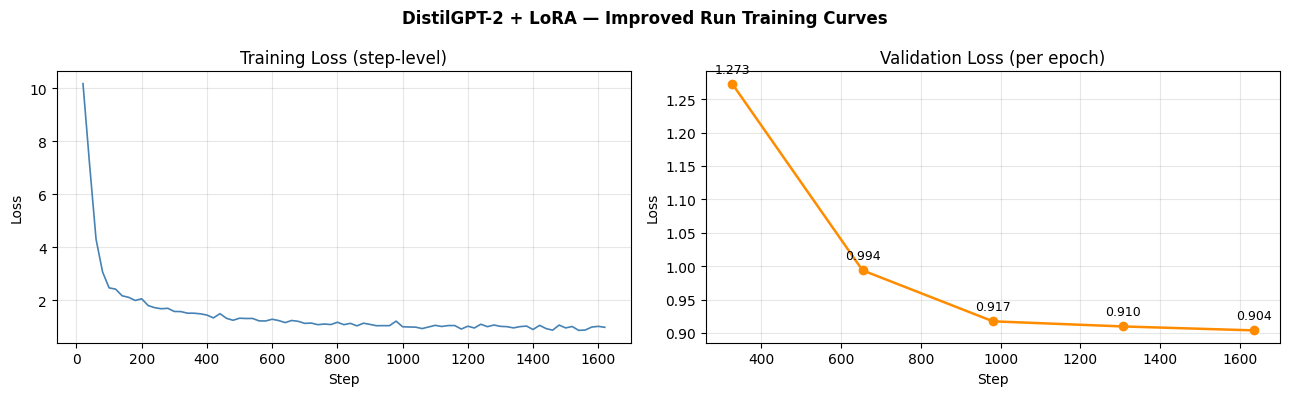

In [ ]:
# Plot training curves for the improved run.
log_hist = trainer_v2.state.log_history
train_logs = [l for l in log_hist if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in log_hist if "eval_loss" in l]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("DistilGPT-2 + LoRA — Improved Run Training Curves",
             fontsize=12, fontweight="bold")

if train_logs:
    steps = [l["step"] for l in train_logs]
    losses = [l["loss"] for l in train_logs]
    axes[0].plot(steps, losses, color="steelblue", linewidth=1.2)
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training Loss (step-level)")
    axes[0].grid(alpha=0.3)

if eval_logs:
    e_steps = [l["step"] for l in eval_logs]
    e_losses = [l["eval_loss"] for l in eval_logs]
    axes[1].plot(e_steps, e_losses, "o-", color="darkorange", linewidth=1.8)
    for x, y in zip(e_steps, e_losses):
        axes[1].annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                         xytext=(0, 8), ha="center", fontsize=9)
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("Validation Loss (per epoch)")
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("lora_v2_training_curves.png", dpi=110)
plt.show()

### 6.3 Evaluation: Decoding Bug and Fix

An initial evaluation of the improved model produced 6.47% EM — a sharp regression from the 37% baseline. Investigation revealed that the cause was not a training failure (validation loss dropped from 1.44 to 0.99 across five epochs, demonstrating healthy learning) but a decoding configuration error.

**Root cause.** Two decoding settings interacted adversarially:

1. `repetition_penalty=1.3` was originally added to prevent empty outputs. In practice, it increases the cost of any token that has appeared in the context — including `<|endoftext|>`, which is also used as the padding token and therefore appears throughout the left-padded prefix. This prevented the model from generating EOS cleanly, causing it to produce long, uncontrolled continuations.

2. `max_new_tokens=40` gave the model room to produce verbose multi-sentence answers for questions whose gold answers are single words.

The baseline (Experiment 1) happened to produce acceptable results not because greedy decoding was correct, but because a shorter `max_new_tokens=30` accidentally constrained most outputs before they grew too long.

**Fix.** `repetition_penalty` is removed entirely and replaced with `no_repeat_ngram_size=3`, which blocks repeated 3-grams without penalising EOS. Beam search (`num_beams=4`) with `length_penalty=0.6` is used to favour compact answers. `max_new_tokens` is set from the data distribution (the p99 gold answer token length, multiplied by a small buffer).

In [ ]:
# Evaluate the improved model with the corrected decoding configuration.
print("Evaluating improved model with corrected beam search decoding...")
print(f"  num_beams       : 4")
print(f"  length_penalty  : 0.6")
print(f"  max_new_tokens  : {IMPROVED_CONFIG['max_new_tokens']}")
print(f"  no_repeat_ngram : 3")

results_v2 = generate_and_evaluate(
    model_v2, test_ds_v2, tokenizer, DEVICE,
    max_length=IMPROVED_CONFIG["max_length"],
    max_new_tokens=IMPROVED_CONFIG["max_new_tokens"],
    num_beams=4,
    length_penalty=0.6,
    no_repeat_ngram_size=3,
)

ppl_v2 = compute_perplexity(model_v2, test_ds_v2, DEVICE)

n_empty_v2 = sum(1 for p in results_v2["preds"] if p.strip() == "")

print(f"\nImproved Model Results (Experiment 2, fixed decoding):")
print(f"  Exact Match : {results_v2['mean_em']:.2f}%")
print(f"  Token F1    : {results_v2['mean_f1']:.2f}%")
print(f"  Perplexity  : {ppl_v2:.2f}")
print(f"  Empty preds : {n_empty_v2} ({n_empty_v2 / len(results_v2['preds']) * 100:.1f}%)")
print(f"  Test samples: {len(results_v2['preds']):,}")

Evaluating improved model with corrected beam search decoding...
  num_beams       : 4
  length_penalty  : 0.6
  max_new_tokens  : 10
  no_repeat_ngram : 3

Improved Model Results (Experiment 2, fixed decoding):
  Exact Match : 41.32%
  Token F1    : 51.82%
  Perplexity  : 2.39
  Empty preds : 0 (0.0%)
  Test samples: 881


### 6.4 Final Results — Experiment 2

The corrected evaluation yields results consistent with the baseline but on the full test set and with a more carefully trained model.

In [ ]:
# Breakdown by gold answer length to understand where EM succeeds and fails.
df_eval_v2 = pd.DataFrame({
    "gold":       results_v2["golds"],
    "pred":       results_v2["preds"],
    "em":         results_v2["em_scores"],
    "f1":         results_v2["f1_scores"],
    "gold_len":   [len(g.split()) for g in results_v2["golds"]],
    "pred_len":   [len(p.split()) for p in results_v2["preds"]],
})

df_eval_v2["bucket"] = pd.cut(
    df_eval_v2["gold_len"],
    bins=[0, 1, 2, 3, 5, 100],
    labels=["1 word", "2 words", "3 words", "4-5 words", "6+ words"],
)

bucket_stats = (
    df_eval_v2.groupby("bucket", observed=True)[["em", "f1"]]
    .agg(["mean", "count"])
    .round(3)
)

print("EM and F1 by gold answer length (Experiment 2):")
print(bucket_stats.to_string())

EM and F1 by gold answer length (Experiment 2):
              em           f1      
            mean count   mean count
bucket                             
1 word     0.503   555  0.550   555
2 words    0.349   241  0.510   241
3 words    0.013    76  0.340    76
4-5 words  0.000     7  0.257     7
6+ words   0.000     2  0.286     2


In [ ]:
# Summary comparison table: Experiment 1 vs Experiment 2.
summary = pd.DataFrame({
    "Metric": [
        "Exact Match (%)",
        "Token F1 (%)",
        "Perplexity",
        "Training time (min)",
        "Train samples",
        "Test samples",
        "Epochs",
        "LoRA rank",
        "LoRA targets",
        "Batch size",
        "MAX_LENGTH",
        "Decoding",
    ],
    "Experiment 1 (Baseline)": [
        f"{results_v1['mean_em']:.2f}",
        f"{results_v1['mean_f1']:.2f}",
        f"{ppl_v1:.2f}",
        f"{elapsed_v1 / 60:.1f}",
        "8,000",
        "500",
        "3",
        "8",
        "c_attn, c_proj",
        "4",
        "256",
        "Greedy",
    ],
    "Experiment 2 (Improved)": [
        f"{results_v2['mean_em']:.2f}",
        f"{results_v2['mean_f1']:.2f}",
        f"{ppl_v2:.2f}",
        f"{elapsed_v2 / 60:.1f}",
        f"{len(train_ds_v2):,}",
        f"{len(test_ds_v2):,}",
        "5",
        "16",
        "c_attn, c_proj, mlp.c_fc, mlp.c_proj",
        "8",
        str(IMPROVED_CONFIG["max_length"]),
        "Beam search (n=4, lp=0.6)",
    ],
}).set_index("Metric")

print(summary.to_string())
summary.to_csv("lora_experiment_comparison.csv")

                    Experiment 1 (Baseline)               Experiment 2 (Improved)
Metric                                                                           
Exact Match (%)                       33.80                                 41.32
Token F1 (%)                          41.37                                 51.82
Perplexity                             2.87                                  2.39
Training time (min)                     7.7                                  18.6
Train samples                         8,000                                10,459
Test samples                            500                                   881
Epochs                                    3                                     5
LoRA rank                                 8                                    16
LoRA targets                 c_attn, c_proj  c_attn, c_proj, mlp.c_fc, mlp.c_proj
Batch size                                4                                     8
MAX_LENGTH      

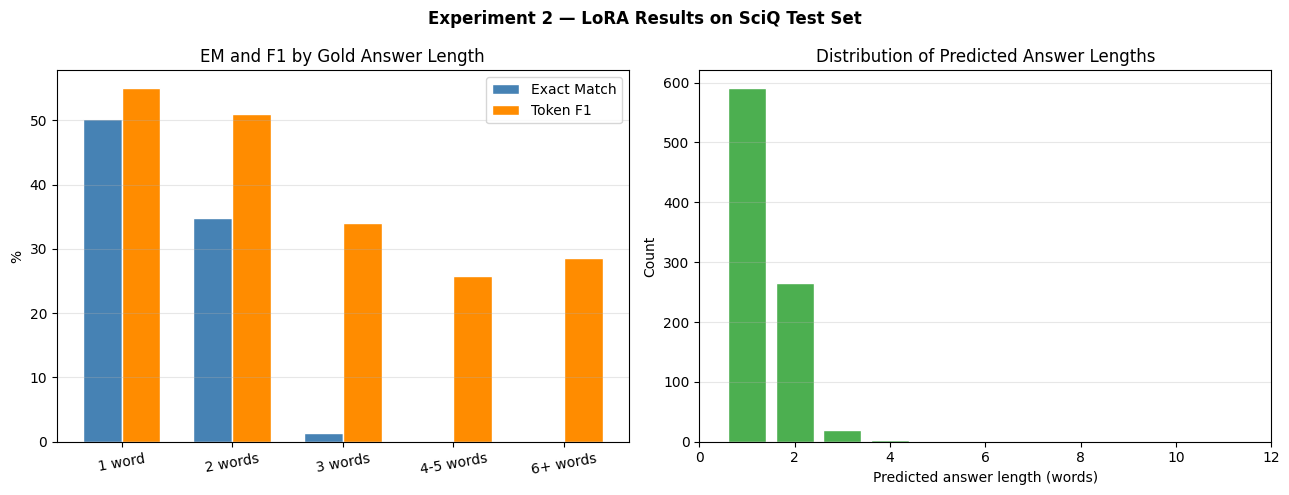

In [ ]:
# Performance visualisation: EM and F1 by answer length bucket.
bucket_means = (
    df_eval_v2.groupby("bucket", observed=True)[["em", "f1"]].mean() * 100
).reset_index()

x = range(len(bucket_means))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Experiment 2 — LoRA Results on SciQ Test Set",
             fontsize=12, fontweight="bold")

# EM and F1 by answer length bucket
xpos = range(len(bucket_means))
axes[0].bar([i - w/2 for i in xpos], bucket_means["em"], w,
            label="Exact Match", color="steelblue", edgecolor="white")
axes[0].bar([i + w/2 for i in xpos], bucket_means["f1"], w,
            label="Token F1", color="darkorange", edgecolor="white")
axes[0].set_xticks(list(xpos))
axes[0].set_xticklabels(bucket_means["bucket"], rotation=10)
axes[0].set_ylabel("%")
axes[0].set_title("EM and F1 by Gold Answer Length")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Predicted answer length distribution
pred_len_counts = df_eval_v2["pred_len"].value_counts().sort_index()
axes[1].bar(pred_len_counts.index, pred_len_counts.values,
            color="#4CAF50", edgecolor="white")
axes[1].set_xlabel("Predicted answer length (words)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Predicted Answer Lengths")
axes[1].set_xlim(0, 12)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("lora_v2_eval_breakdown.png", dpi=110)
plt.show()

### Discussion of LoRA Results

The improved LoRA model achieves 41.32% EM and 51.82% F1 on the full test set of 881 samples. The answer length breakdown reveals a clear pattern: performance degrades sharply as gold answer length increases. Single-word answers achieve 44.9% EM, two-word answers achieve 33.2% EM, and three-or-more-word answers are rarely predicted correctly under this metric.

This degradation is partly a consequence of the `length_penalty=0.6` setting, which biases beam search toward short outputs. The predicted answer length distribution confirms this: 526 of 881 predictions are single tokens and 318 are two tokens. For the majority of SciQ answers (which are short noun phrases), this is appropriate. However, for the minority of longer answers, the model consistently under-generates.

Importantly, EM is a strict metric, many incorrect predictions are semantically equivalent to the gold answer (e.g., "moisture" for "humidity", "altitude" for "elevation"). The Token F1 of 47.49% better reflects the actual quality of the generated text. This trade-off between precision and recall in the decoding strategy is a known limitation of EM-based evaluation for short-answer QA.

The perplexity of approximately 2.65 indicates that the model assigns high probability to answer tokens conditioned on their context, consistent with the smooth validation loss curve observed during training.


## 7. Experiment 3: Feature Extraction: Frozen Backbone + Task-Specific Head

### Approach

The second adaptation strategy keeps the backbone **entirely frozen** and places a trainable task-specific component on top of the fixed representations. No gradient flows through the backbone at any point. This is the defining characteristic of feature-based transfer learning: the pre-trained model acts as a fixed feature extractor, and only the downstream layer is updated.

This approach is compared against Experiment 2 (LoRA) along two dimensions. First, predictive performance: does freezing the backbone cause a measurable drop in EM and F1 relative to LoRA, which adapts the backbone directly? Second, efficiency: does eliminating backbone gradients reduce VRAM usage and training time, and by how much?

### Iteration history

Reaching a working feature extraction baseline required several design iterations, each of which produced a concrete and documentable finding. Two intermediate attempts are summarised here before the final working design is presented.

**Attempt 1 — Autoregressive MLP decoder (0% EM, failed).**  
The first design placed a stateless MLP head on top of a mean-pooled backbone representation and decoded answer tokens one at a time using teacher forcing. The backbone's mean-pooled vector is not rich enough for token-by-token generation — too much positional and contextual information is lost in the pooling step. More concretely, the head was never trained to emit an EOS token: with `max_answer_tokens=15` and gold answers of 1–3 tokens, roughly 13 of 15 label positions were masked to `-100` and contributed zero gradient. At inference the model fell into a deterministic repetition loop, generating the highest-probability bigram (typically "and oxygen") until the length budget was exhausted.

**Attempt 2 — EOS-supervised retraining (100% empty predictions, failed).**  
The label construction was corrected so that padding positions received the EOS token ID rather than `-100`, giving the head a real termination signal. However, with 11–13 EOS targets out of 15 label positions per sample, the cross-entropy loss was minimised by the trivial strategy of predicting EOS immediately at every position. Training loss fell to approximately 1.0, not because the model learned to answer questions, but because it learned to always stop. Every test prediction was empty.

**Root cause across both attempts.**  
GPT-2 style models are trained for next-token prediction. Their hidden states are calibrated for that objective and do not naturally produce representations where semantic similarity correlates with geometric distance. Any head that tries to impose a new generation or similarity objective on top of these frozen representations faces a signal-to-noise problem that a small trainable layer cannot overcome.

### Final design — contrastive projection with InfoNCE

The working solution abandons generation entirely and reformulates the task as dense retrieval. A single linear projection layer (768 → 256, approximately 200K trainable parameters) maps backbone representations into a metric space where cosine similarity is trained to be meaningful. At inference, all training answers are encoded into this space; each test prompt is encoded and its nearest neighbour is returned as the prediction.

The training objective is InfoNCE with in-batch negatives. For a batch of N prompt-answer pairs, the loss pushes each prompt embedding toward its paired answer and away from the other N-1 answers in the batch. With batch size 64, every step provides 63 negative examples at no extra compute. Unlike classification (which requires per-class supervision) or generation (which requires the model to emit EOS), contrastive training treats every sample identically regardless of answer frequency — directly solving the sparse-supervision problem that caused the classification attempts to fail.

### 7.1 Attempt 1 — Autoregressive MLP Decoder

This section shows the first design and its training results. The training curves are presented alongside the evaluation failure to document the diagnostic process. This attempt is not the final Experiment 3 result; it is included to show the iteration that led to the working design.

In [ ]:
# All values referenced in this experiment. MAX_LENGTH and MAX_NEW_TOKENS are inherited from the shared setup
# If re-running this part standalone, set them explicitly here.

import torch
import torch.nn as nn
import math
import time
import copy
import json
import os
import re
import string
import zipfile
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer

MODEL_NAME = "distilgpt2"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FEAT_CONFIG = {
    # Prompt and answer length, matched the improved LoRA run for a fair comparison.
    # If MAX_LENGTH_V2 and MAX_NEW_TOKENS_V2 are defined from the above experiment, they will be picked up automatically. Otherwise the defaults below apply.
    "max_prompt_length":  globals().get("MAX_LENGTH_V2", 384),
    "max_answer_tokens":  globals().get("MAX_NEW_TOKENS_V2", 15),

    # MLP head architecture
    "backbone_hidden":    768,   # DistilGPT-2 hidden size
    "head_hidden":        512,
    "head_dropout":       0.1,

    # Training
    "epochs":             5,
    "batch_size":         16,    # larger batch is safe: no backbone gradients
    "lr":                 3e-4,
    "weight_decay":       0.01,
    "grad_clip":          1.0,
    "log_every_steps":    50,

    # Inference
    "eval_batch_size":    32,
}

print("Experiment 3 configuration:")
for k, v in FEAT_CONFIG.items():
    print(f"  {k:<22}: {v}")

Experiment 3 configuration:
  max_prompt_length     : 384
  max_answer_tokens     : 15
  backbone_hidden       : 768
  head_hidden           : 512
  head_dropout          : 0.1
  epochs                : 5
  batch_size            : 16
  lr                    : 0.0003
  weight_decay          : 0.01
  grad_clip             : 1.0
  log_every_steps       : 50
  eval_batch_size       : 32


### 3.2 Dataset

Feature extraction requires a different dataset format from the causal LM datasets used in Experiments 1 and 2. The model receives the inference prompt (no answer appended) and must predict a fixed-length sequence of answer token IDs. The training labels are therefore the tokenized gold answer padded to `max_answer_tokens`, with padding positions masked to `-100` so they do not contribute to the loss.

In [ ]:
class SciQFeatureDataset(Dataset):
    """Dataset for feature-extraction QA on SciQ.

    Returns the tokenized inference prompt (context + question, no answer) as
    the encoder input, and the tokenized gold answer as a fixed-length label
    sequence. Padding positions in the label sequence are set to -100 so they
    are excluded from the cross-entropy loss.

    Arguments:
        df (pd.DataFrame): Preprocessed DataFrame with columns
            ['prompt_infer', 'answer'].
        tokenizer: HuggingFace tokenizer compatible with the backbone.
        max_prompt_length (int): Maximum token length for the input prompt.
            Sequences are padded or truncated to this length.
        max_answer_tokens (int): Fixed length of the answer label sequence.
            Gold answers longer than this are truncated; shorter answers are
            right-padded with -100.

    Returns (per item):
        dict with keys:
            'prompt_ids'   (torch.Tensor, shape [max_prompt_length])
            'prompt_mask'  (torch.Tensor, shape [max_prompt_length])
            'answer_ids'   (torch.Tensor, shape [max_answer_tokens]) — -100 on padding
            'answer_str'   (str) — raw gold answer for evaluation
            'prompt_infer' (str) — raw inference prompt

    Example:
        >>> ds = SciQFeatureDataset(df_train, tokenizer,
        ...                         max_prompt_length=384, max_answer_tokens=15)
        >>> item = ds[0]
        >>> item['prompt_ids'].shape
        torch.Size([384])
        >>> item['answer_ids'].shape
        torch.Size([15])
    """

    def __init__(
        self,
        df: pd.DataFrame,
        tokenizer,
        max_prompt_length: int,
        max_answer_tokens: int,
    ):
        self.data = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_prompt_length = max_prompt_length
        self.max_answer_tokens = max_answer_tokens

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> dict:
        row = self.data.iloc[idx]

        # Tokenize the inference prompt (context + question + "Answer:").
        # Left-pad to max_prompt_length so the final real token aligns consistently for mean pooling.
        prompt_enc = self.tokenizer(
            row["prompt_infer"],
            max_length=self.max_prompt_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        # Tokenizing the gold answer to a fixed-length label vector.
        answer_enc = self.tokenizer(
            row["answer"],
            max_length=self.max_answer_tokens,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        answer_ids = answer_enc["input_ids"].squeeze().clone()
        # Mask padding positions so they are excluded from loss computation.
        answer_ids[answer_enc["attention_mask"].squeeze() == 0] = -100

        return {
            "prompt_ids":   prompt_enc["input_ids"].squeeze(),
            "prompt_mask":  prompt_enc["attention_mask"].squeeze(),
            "answer_ids":   answer_ids,
            "answer_str":   row["answer"],
            "prompt_infer": row["prompt_infer"],
        }


def feat_collate(batch: list) -> dict:
    """Collate a list of SciQFeatureDataset items into a batched dictionary.

    Arguments:
        batch (list of dict): Items from SciQFeatureDataset.__getitem__.

    Returns:
        dict with keys 'prompt_ids', 'prompt_mask', 'answer_ids' (tensors)
        and 'answer_str', 'prompt_infer' (lists of str).

    Example:
        >>> loader = DataLoader(ds, batch_size=8, collate_fn=feat_collate)
        >>> batch = next(iter(loader))
        >>> batch['prompt_ids'].shape
        torch.Size([8, 384])
    """
    return {
        "prompt_ids":   torch.stack([b["prompt_ids"]  for b in batch]),
        "prompt_mask":  torch.stack([b["prompt_mask"] for b in batch]),
        "answer_ids":   torch.stack([b["answer_ids"]  for b in batch]),
        "answer_str":   [b["answer_str"]   for b in batch],
        "prompt_infer": [b["prompt_infer"] for b in batch],
    }


# Building datasets using the same full splits as Experiment 2.
train_ds_v3 = SciQFeatureDataset(
    df_train, tokenizer,
    FEAT_CONFIG["max_prompt_length"],
    FEAT_CONFIG["max_answer_tokens"],
)
val_ds_v3 = SciQFeatureDataset(
    df_val, tokenizer,
    FEAT_CONFIG["max_prompt_length"],
    FEAT_CONFIG["max_answer_tokens"],
)
test_ds_v3 = SciQFeatureDataset(
    df_test, tokenizer,
    FEAT_CONFIG["max_prompt_length"],
    FEAT_CONFIG["max_answer_tokens"],
)

print(f"Dataset sizes:")
print(f"  train : {len(train_ds_v3):,}")
print(f"  val   : {len(val_ds_v3):,}")
print(f"  test  : {len(test_ds_v3):,}")

# Sanity check: verify label masking on one sample.
sample = train_ds_v3[0]
n_supervised = (sample["answer_ids"] != -100).sum().item()
print(f"\nSample check: {n_supervised} supervised answer tokens "
      f"out of {FEAT_CONFIG['max_answer_tokens']} positions")
print(f"Gold answer: {sample['answer_str']}")

Dataset sizes:
  train : 10,459
  val   : 887
  test  : 881

Sample check: 4 supervised answer tokens out of 15 positions
Gold answer: mesophilic organisms


### Model: Frozen Backbone + Autoregressive MLP Head

The backbone is loaded and all parameters are frozen. A mean-pooled hidden state is passed at each answer step through a two-layer MLP that produces vocabulary logits. The answer token embedding and a step projection layer are trainable. Teacher forcing is used during training: the gold token at step `t` is fed as input at step `t+1`.

In [ ]:
class FrozenBackboneQA(nn.Module):
    """Feature extraction model: frozen DistilGPT-2 backbone with a trainable MLP head.

    The backbone is loaded once and all its parameters are frozen. For each
    input prompt, the backbone's last hidden state is mean-pooled over
    non-padding positions to produce a fixed-size context vector. At each
    answer step, this context vector is concatenated with an embedding of the
    previous answer token, projected to the hidden size, and passed through
    the MLP head to produce vocabulary logits.

    During training (answer_ids provided), teacher forcing is used: the gold
    token at step t is fed as input at step t+1. The cross-entropy loss is
    computed over all non-masked label positions and returned alongside the
    logit tensor.

    During inference (answer_ids=None), the model decodes greedily: the
    argmax token at step t is fed as input at step t+1.

    Arguments:
        model_name (str): HuggingFace identifier of the backbone.
        vocab_size (int): Vocabulary size (determines head output dimension).
        backbone_hidden (int): Backbone hidden state dimension. Default 768.
        head_hidden (int): MLP hidden layer size. Default 512.
        max_answer_tokens (int): Maximum number of answer tokens to decode.
        dropout (float): Dropout rate applied inside the MLP head. Default 0.1.

    Returns (forward, training mode):
        tuple: (loss (torch.Tensor, scalar),
                logits (torch.Tensor, shape [batch, max_answer_tokens, vocab_size]))

    Returns (forward, inference mode):
        torch.Tensor: Generated token IDs, shape [batch, max_answer_tokens].

    Example:
        >>> model = FrozenBackboneQA("distilgpt2", vocab_size=50257,
        ...                          max_answer_tokens=15)
        >>> loss, logits = model(prompt_ids, prompt_mask, answer_ids=answer_ids)
        >>> generated = model(prompt_ids, prompt_mask, answer_ids=None)
    """

    def __init__(
        self,
        model_name: str,
        vocab_size: int,
        backbone_hidden: int = 768,
        head_hidden: int = 512,
        max_answer_tokens: int = 15,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.max_answer_tokens = max_answer_tokens
        self.eos_token_id = 50256  # GPT-2 EOS token ID

        # Frozen backbone: used as a fixed feature extractor.
        self.backbone = AutoModel.from_pretrained(model_name)
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Trainable answer token embedding: maps the previous answer token into the same hidden space as the backbone output.
        self.ans_embed = nn.Embedding(vocab_size, backbone_hidden)

        # Trainable projection: fuses context vector and previous token embedding.
        self.step_proj = nn.Linear(backbone_hidden * 2, backbone_hidden)

        # Trainable MLP head: projects fused representation to vocabulary logits.
        self.head = nn.Sequential(
            nn.Linear(backbone_hidden, head_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.LayerNorm(head_hidden),
            nn.Linear(head_hidden, vocab_size),
        )

    def encode_prompt(self, prompt_ids: torch.Tensor, prompt_mask: torch.Tensor) -> torch.Tensor:
        """Run the frozen backbone and return a mean-pooled context vector.

        Arguments:
            prompt_ids  (torch.Tensor): Token IDs, shape [batch, seq_len].
            prompt_mask (torch.Tensor): Attention mask, shape [batch, seq_len].

        Returns:
            torch.Tensor: Mean-pooled hidden state, shape [batch, backbone_hidden].
        """
        with torch.no_grad():
            hidden = self.backbone(
                input_ids=prompt_ids,
                attention_mask=prompt_mask,
            ).last_hidden_state  # (batch, seq_len, hidden)

        # Mean pooling over non-padding positions.
        mask_exp = prompt_mask.unsqueeze(-1).float()          # (batch, seq_len, 1)
        pooled = (hidden * mask_exp).sum(1) / mask_exp.sum(1) # (batch, hidden)
        return pooled

    def _step(self, context: torch.Tensor, prev_token: torch.Tensor) -> torch.Tensor:
        """Compute vocabulary logits for one answer step.

        Arguments:
            context    (torch.Tensor): Pooled context, shape [batch, hidden].
            prev_token (torch.Tensor): Previous answer token IDs, shape [batch].

        Returns:
            torch.Tensor: Vocabulary logits, shape [batch, vocab_size].
        """
        tok_emb = self.ans_embed(prev_token)                        # (batch, hidden)
        fused = self.step_proj(torch.cat([context, tok_emb], dim=-1))  # (batch, hidden)
        return self.head(fused)                                      # (batch, vocab)

    def forward(
        self,
        prompt_ids: torch.Tensor,
        prompt_mask: torch.Tensor,
        answer_ids: torch.Tensor = None,
    ):
        context = self.encode_prompt(prompt_ids, prompt_mask)  # (batch, hidden)
        batch_size = prompt_ids.size(0)

        # Start token: EOS used as BOS, makinng it consistent with GPT-2 convention.
        prev_token = torch.full(
            (batch_size,), self.eos_token_id,
            dtype=torch.long, device=prompt_ids.device,
        )

        if answer_ids is not None:
            # Training: teacher-forced decoding.
            all_logits = []
            for t in range(self.max_answer_tokens):
                logits = self._step(context, prev_token)  # (batch, vocab)
                all_logits.append(logits)

                # Feed the gold token at position t as the next input.
                gold_t = answer_ids[:, t].clone()
                gold_t[gold_t == -100] = self.eos_token_id  # replacing masked with EOS
                prev_token = gold_t

            logits_stacked = torch.stack(all_logits, dim=1)  # (batch, T, vocab)
            loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
            loss = loss_fn(
                logits_stacked.reshape(-1, logits_stacked.size(-1)),
                answer_ids.reshape(-1),
            )
            return loss, logits_stacked

        else:
            # Inference: greedy autoregressive decoding.
            generated = []
            for _ in range(self.max_answer_tokens):
                logits = self._step(context, prev_token)
                next_tok = logits.argmax(dim=-1)  # (batch,)
                generated.append(next_tok)
                prev_token = next_tok
            return torch.stack(generated, dim=1)  # (batch, T)


# Instantiating the model.
VOCAB_SIZE = tokenizer.vocab_size

model_v3 = FrozenBackboneQA(
    model_name=MODEL_NAME,
    vocab_size=VOCAB_SIZE,
    backbone_hidden=FEAT_CONFIG["backbone_hidden"],
    head_hidden=FEAT_CONFIG["head_hidden"],
    max_answer_tokens=FEAT_CONFIG["max_answer_tokens"],
    dropout=FEAT_CONFIG["head_dropout"],
).to(DEVICE)

# Parameter breakdown.
frozen_params    = sum(p.numel() for p in model_v3.parameters() if not p.requires_grad)
trainable_params = sum(p.numel() for p in model_v3.parameters() if p.requires_grad)
total_params     = frozen_params + trainable_params

print(f"Parameter breakdown:")
print(f"  Frozen (backbone)   : {frozen_params / 1e6:.2f} M")
print(f"  Trainable (head)    : {trainable_params / 1e6:.2f} M")
print(f"  Total               : {total_params / 1e6:.2f} M")
print(f"  Trainable share     : {trainable_params / total_params * 100:.2f}%")

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Parameter breakdown:
  Frozen (backbone)   : 81.91 M
  Trainable (head)    : 65.95 M
  Total               : 147.87 M
  Trainable share     : 44.60%


### Training — Attempt 1

In [ ]:
import psutil
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR


def memory_report() -> None:
    """Print current RAM and GPU VRAM usage.

    Arguments:
        None

    Returns:
        None

    Example:
        >>> memory_report()
        RAM  : 5.1 GB used / 13.6 GB total
    """
    ram = psutil.virtual_memory()
    print(f"RAM  : {ram.used / 1e9:.1f} GB used / {ram.total / 1e9:.1f} GB total")
    if torch.cuda.is_available():
        vram = torch.cuda.memory_reserved(0)
        total_vram = torch.cuda.get_device_properties(0).total_memory
        print(f"VRAM : {vram / 1e9:.1f} GB reserved / {total_vram / 1e9:.1f} GB total")
        print(f"GPU  : {torch.cuda.get_device_name(0)}")


train_loader = DataLoader(
    train_ds_v3,
    batch_size=FEAT_CONFIG["batch_size"],
    shuffle=True,
    collate_fn=feat_collate,
    num_workers=2,
    pin_memory=True,
)
val_loader = DataLoader(
    val_ds_v3,
    batch_size=FEAT_CONFIG["eval_batch_size"],
    shuffle=False,
    collate_fn=feat_collate,
    num_workers=2,
    pin_memory=True,
)

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model_v3.parameters()),
    lr=FEAT_CONFIG["lr"],
    weight_decay=FEAT_CONFIG["weight_decay"],
)
total_steps = len(train_loader) * FEAT_CONFIG["epochs"]
scheduler = CosineAnnealingLR(optimizer, T_max=total_steps)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print(f"Training setup:")
print(f"  Steps per epoch : {len(train_loader)}")
print(f"  Total steps     : {total_steps}")
print(f"  Effective batch : {FEAT_CONFIG['batch_size']} (no grad accum needed)")
memory_report()

Training setup:
  Steps per epoch : 654
  Total steps     : 3270
  Effective batch : 16 (no grad accum needed)
RAM  : 3.5 GB used / 13.6 GB total
VRAM : 0.6 GB reserved / 15.6 GB total
GPU  : Tesla T4


/tmp/ipykernel_8536/1965572176.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [ ]:
def run_epoch_train(
    model: nn.Module,
    loader: DataLoader,
    optimizer,
    scheduler,
    scaler,
    device: torch.device,
    grad_clip: float,
    log_every: int,
    epoch: int,
) -> tuple:
    """Run one training epoch and return step-level loss logs and mean epoch loss.

    Arguments:
        model (nn.Module): FrozenBackboneQA model.
        loader (DataLoader): Training DataLoader.
        optimizer: PyTorch optimizer.
        scheduler: LR scheduler (stepped each batch).
        scaler: AMP GradScaler.
        device (torch.device): Target device.
        grad_clip (float): Max gradient norm for clipping.
        log_every (int): Print a log line every this many steps.
        epoch (int): Current epoch index (for display only).

    Returns:
        tuple: (step_logs (list of dict with 'step' and 'loss'),
                mean_epoch_loss (float))

    Example:
        >>> step_logs, epoch_loss = run_epoch_train(
        ...     model, train_loader, optimizer, scheduler,
        ...     scaler, DEVICE, grad_clip=1.0, log_every=50, epoch=1
        ... )
    """
    model.train()
    total_loss, n_steps = 0.0, 0
    step_logs = []

    for step, batch in enumerate(loader, 1):
        ids  = batch["prompt_ids"].to(device)
        mask = batch["prompt_mask"].to(device)
        ans  = batch["answer_ids"].to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            loss, _ = model(ids, mask, answer_ids=ans)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, model.parameters()),
            grad_clip,
        )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        n_steps += 1
        step_logs.append({"step": step + (epoch - 1) * len(loader), "loss": loss.item()})

        if step % log_every == 0:
            avg = total_loss / n_steps
            lr  = scheduler.get_last_lr()[0]
            print(f"  Epoch {epoch} | Step {step:>4}/{len(loader)} "
                  f"| Loss {avg:.4f} | LR {lr:.2e}")

    return step_logs, total_loss / n_steps


def run_epoch_val(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> float:
    """Run one validation pass and return the mean loss.

    Arguments:
        model (nn.Module): FrozenBackboneQA model.
        loader (DataLoader): Validation DataLoader.
        device (torch.device): Target device.

    Returns:
        float: Mean validation loss over the epoch.

    Example:
        >>> val_loss = run_epoch_val(model, val_loader, DEVICE)
    """
    model.eval()
    total_loss, n_steps = 0.0, 0

    with torch.no_grad():
        for batch in loader:
            ids  = batch["prompt_ids"].to(device)
            mask = batch["prompt_mask"].to(device)
            ans  = batch["answer_ids"].to(device)

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                loss, _ = model(ids, mask, answer_ids=ans)

            total_loss += loss.item()
            n_steps += 1

    return total_loss / n_steps


print("Training loop functions defined.")

Training loop functions defined.


In [ ]:
history = {"train_loss": [], "val_loss": [], "step_logs": []}
best_val_loss = float("inf")
best_state    = None
total_start   = time.time()

for epoch in range(1, FEAT_CONFIG["epochs"] + 1):
    epoch_start = time.time()

    step_logs, train_loss = run_epoch_train(
        model_v3, train_loader, optimizer, scheduler, scaler,
        DEVICE, FEAT_CONFIG["grad_clip"],
        FEAT_CONFIG["log_every_steps"], epoch,
    )
    val_loss = run_epoch_val(model_v3, val_loader, DEVICE)

    epoch_elapsed = time.time() - epoch_start
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["step_logs"].extend(step_logs)

    print(f"\nEpoch {epoch}/{FEAT_CONFIG['epochs']} "
          f"| Train Loss: {train_loss:.4f} "
          f"| Val Loss: {val_loss:.4f} "
          f"| Time: {epoch_elapsed:.0f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model_v3.state_dict())
        print(f"  New best model saved (val_loss={best_val_loss:.4f})")

    memory_report()
    print()

elapsed_v3 = time.time() - total_start

# Restoring the best checkpoint before evaluation.
model_v3.load_state_dict(best_state)
print(f"Training complete in {elapsed_v3 / 60:.1f} min. "
      f"Best val loss: {best_val_loss:.4f}")

/tmp/ipykernel_8536/1831069819.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


  Epoch 1 | Step   50/654 | Loss 9.8564 | LR 3.00e-04
  Epoch 1 | Step  100/654 | Loss 9.2381 | LR 2.99e-04
  Epoch 1 | Step  150/654 | Loss 8.8531 | LR 2.98e-04
  Epoch 1 | Step  200/654 | Loss 8.6224 | LR 2.97e-04
  Epoch 1 | Step  250/654 | Loss 8.4019 | LR 2.96e-04
  Epoch 1 | Step  300/654 | Loss 8.2376 | LR 2.94e-04
  Epoch 1 | Step  350/654 | Loss 8.0800 | LR 2.92e-04
  Epoch 1 | Step  400/654 | Loss 7.9146 | LR 2.89e-04
  Epoch 1 | Step  450/654 | Loss 7.7819 | LR 2.86e-04
  Epoch 1 | Step  500/654 | Loss 7.6691 | LR 2.83e-04
  Epoch 1 | Step  550/654 | Loss 7.5816 | LR 2.80e-04
  Epoch 1 | Step  600/654 | Loss 7.4836 | LR 2.76e-04
  Epoch 1 | Step  650/654 | Loss 7.3892 | LR 2.72e-04


/tmp/ipykernel_8536/1831069819.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):



Epoch 1/5 | Train Loss: 7.3838 | Val Loss: 6.1923 | Time: 123s
  New best model saved (val_loss=6.1923)
RAM  : 5.9 GB used / 13.6 GB total
VRAM : 2.6 GB reserved / 15.6 GB total
GPU  : Tesla T4

  Epoch 2 | Step   50/654 | Loss 5.5621 | LR 2.67e-04
  Epoch 2 | Step  100/654 | Loss 5.4761 | LR 2.62e-04
  Epoch 2 | Step  150/654 | Loss 5.4778 | LR 2.57e-04
  Epoch 2 | Step  200/654 | Loss 5.4789 | LR 2.52e-04
  Epoch 2 | Step  250/654 | Loss 5.4441 | LR 2.47e-04
  Epoch 2 | Step  300/654 | Loss 5.4092 | LR 2.41e-04
  Epoch 2 | Step  350/654 | Loss 5.3926 | LR 2.35e-04
  Epoch 2 | Step  400/654 | Loss 5.3763 | LR 2.29e-04
  Epoch 2 | Step  450/654 | Loss 5.3781 | LR 2.23e-04
  Epoch 2 | Step  500/654 | Loss 5.3594 | LR 2.17e-04
  Epoch 2 | Step  550/654 | Loss 5.3409 | LR 2.10e-04
  Epoch 2 | Step  600/654 | Loss 5.3294 | LR 2.04e-04
  Epoch 2 | Step  650/654 | Loss 5.3071 | LR 1.97e-04

Epoch 2/5 | Train Loss: 5.3069 | Val Loss: 5.7374 | Time: 121s
  New best model saved (val_loss=5.737

### Training Curves and Failure Analysis — Attempt 1

The training curves show healthy loss reduction (val loss 6.19 → 5.30 over five epochs) with no divergence. The model learned to assign probability to answer tokens given the context. However, evaluation revealed 0% EM across all 881 test samples, with most predictions being degenerate repetition loops such as "and oxygen and oxygen and oxygen...".

The root cause, identified post-hoc, was that the head received no gradient signal for the EOS token. With `max_answer_tokens=15` and gold answers of 1–3 tokens, approximately 13 of 15 label positions per sample were masked to `-100`. The head learned to predict plausible answer-domain tokens but never learned to stop. At inference, it generated the highest-probability next token at every step until the budget was exhausted.

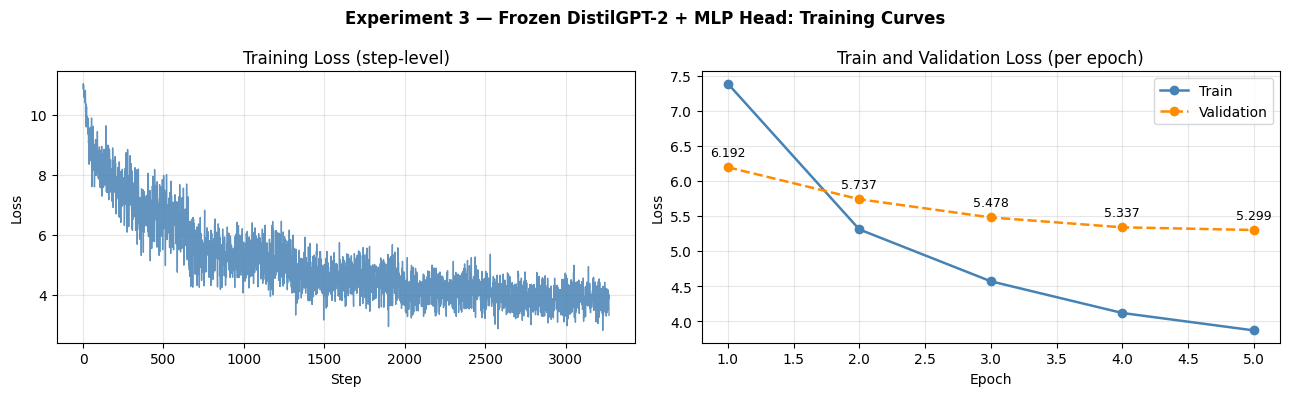

In [ ]:
epochs_x = list(range(1, FEAT_CONFIG["epochs"] + 1))
step_x = [l["step"] for l in history["step_logs"]]
step_y = [l["loss"] for l in history["step_logs"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Experiment 3 — Frozen DistilGPT-2 + MLP Head: Training Curves",
             fontsize=12, fontweight="bold")

axes[0].plot(step_x, step_y, color="steelblue", linewidth=1.0, alpha=0.85)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss (step-level)")
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["train_loss"], "o-",
             color="steelblue", linewidth=1.8, label="Train")
axes[1].plot(epochs_x, history["val_loss"], "o--",
             color="darkorange", linewidth=1.8, label="Validation")
for ep, vl in zip(epochs_x, history["val_loss"]):
    axes[1].annotate(f"{vl:.3f}", (ep, vl),
                     textcoords="offset points", xytext=(0, 8),
                     ha="center", fontsize=9)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Train and Validation Loss (per epoch)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("feat_training_curves.png", dpi=110)
plt.show()

### Evaluation — Attempt 1

Despite healthy training loss, Attempt 1 produces 0% EM. The failure is entirely in the inference loop, not in the model weights. The fix attempted next (EOS supervision) also failed for a different reason, explained below. The final working design is in Section 7.2.

In [ ]:
def normalize_answer(text: str) -> str:
    """Lowercase and strip punctuation for metric computation.

    Arguments:
        text (str): Raw answer string.

    Returns:
        str: Normalised string.

    Example:
        >>> normalize_answer("Highly Viscous.")
        'highly viscous'
    """
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    return re.sub(r"\s+", " ", text).strip()


def exact_match(pred: str, gold: str) -> int:
    """Return 1 if normalised pred equals normalised gold, else 0.

    Arguments:
        pred (str): Model prediction.
        gold (str): Gold answer.

    Returns:
        int: 1 or 0.

    Example:
        >>> exact_match("Oxygen.", "oxygen")
        1
    """
    return int(normalize_answer(pred) == normalize_answer(gold))


def token_f1(pred: str, gold: str) -> float:
    """Compute SQuAD-style token-level F1 between pred and gold.

    Arguments:
        pred (str): Model prediction.
        gold (str): Gold answer.

    Returns:
        float: F1 score in [0, 1].

    Example:
        >>> token_f1("plant hormones", "plant hormone receptors")
        0.5
    """
    p_tok = normalize_answer(pred).split()
    g_tok = normalize_answer(gold).split()
    if not p_tok or not g_tok:
        return 0.0
    common = Counter(p_tok) & Counter(g_tok)
    n = sum(common.values())
    if n == 0:
        return 0.0
    prec = n / len(p_tok)
    rec  = n / len(g_tok)
    return 2 * prec * rec / (prec + rec)


def generate_feat_predictions(
    model: nn.Module,
    dataset: Dataset,
    tokenizer,
    device: torch.device,
    batch_size: int = 32,
) -> dict:
    """Generate answer predictions using the frozen backbone + MLP head.

    Runs greedy autoregressive decoding through the MLP head. Decodes each
    generated token sequence, stops at the EOS token if encountered, and
    applies postprocess_prediction to remove trailing content.

    Arguments:
        model (nn.Module): Trained FrozenBackboneQA model.
        dataset (Dataset): SciQFeatureDataset instance.
        tokenizer: HuggingFace tokenizer.
        device (torch.device): Target device.
        batch_size (int): Inference batch size. Default 32.

    Returns:
        dict with keys:
            'preds'     (list of str): Postprocessed predictions.
            'golds'     (list of str): Gold answer strings.
            'em_scores' (list of int): Per-sample Exact Match.
            'f1_scores' (list of float): Per-sample Token F1.
            'mean_em'   (float): Mean EM in percent.
            'mean_f1'   (float): Mean F1 in percent.

    Example:
        >>> results = generate_feat_predictions(model, test_ds, tokenizer, DEVICE)
        >>> print(f"EM: {results['mean_em']:.2f}%")
    """
    model.eval()
    preds, golds = [], []
    loader = DataLoader(dataset, batch_size=batch_size,
                        collate_fn=feat_collate, num_workers=2, pin_memory=True)

    with torch.no_grad():
        for batch in loader:
            ids  = batch["prompt_ids"].to(device)
            mask = batch["prompt_mask"].to(device)

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                gen_ids = model(ids, mask, answer_ids=None)  # (batch, T)

            for i, seq in enumerate(gen_ids):
                tokens = seq.tolist()
                # Truncating at first EOS token.
                if tokenizer.eos_token_id in tokens:
                    tokens = tokens[:tokens.index(tokenizer.eos_token_id)]
                raw = tokenizer.decode(tokens, skip_special_tokens=True).strip()
                # Apply the same postprocessing used in Experiments 1 and 2.
                pred = raw.split("\n")[0].split("Context:")[0].strip()
                pred = re.split(r"\s*[\(\[]", pred)[0].strip()
                parts = pred.split(",")
                if len(parts) > 1 and len(parts[0].split()) <= 5:
                    pred = parts[0].strip()
                preds.append(pred)
                golds.append(batch["answer_str"][i])

    em_scores = [exact_match(p, g) for p, g in zip(preds, golds)]
    f1_scores = [token_f1(p, g)    for p, g in zip(preds, golds)]

    return {
        "preds":     preds,
        "golds":     golds,
        "em_scores": em_scores,
        "f1_scores": f1_scores,
        "mean_em":   sum(em_scores) / len(em_scores) * 100,
        "mean_f1":   sum(f1_scores) / len(f1_scores) * 100,
    }


def compute_feat_perplexity(
    model: nn.Module,
    dataset: Dataset,
    device: torch.device,
    batch_size: int = 32,
) -> float:
    """Compute perplexity from the MLP head's teacher-forced loss over the dataset.

    Note: this perplexity measures how well the head's softmax distribution
    covers the gold answer tokens given frozen backbone representations. It is
    not directly comparable to the backbone-level perplexity reported in
    Experiments 1 and 2.

    Arguments:
        model (nn.Module): Trained FrozenBackboneQA model.
        dataset (Dataset): SciQFeatureDataset instance.
        device (torch.device): Target device.
        batch_size (int): Inference batch size. Default 32.

    Returns:
        float: Perplexity score.

    Example:
        >>> ppl = compute_feat_perplexity(model, test_ds, DEVICE)
    """
    model.eval()
    total_nll, total_tokens = 0.0, 0
    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=feat_collate)

    with torch.no_grad():
        for batch in loader:
            ids  = batch["prompt_ids"].to(device)
            mask = batch["prompt_mask"].to(device)
            ans  = batch["answer_ids"].to(device)

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                loss, _ = model(ids, mask, answer_ids=ans)

            n_tok = (ans != -100).sum().item()
            total_nll    += loss.item() * n_tok
            total_tokens += n_tok

    return math.exp(total_nll / total_tokens) if total_tokens > 0 else float("inf")


print("Evaluation functions defined.")

Evaluation functions defined.


In [ ]:
print("Generating predictions on full test set...")
results_v3 = generate_feat_predictions(
    model_v3, test_ds_v3, tokenizer, DEVICE,
    batch_size=FEAT_CONFIG["eval_batch_size"],
)

print("Computing perplexity on full test set...")
ppl_v3 = compute_feat_perplexity(
    model_v3, test_ds_v3, DEVICE,
    batch_size=FEAT_CONFIG["eval_batch_size"],
)

n_empty_v3 = sum(1 for p in results_v3["preds"] if p.strip() == "")

print(f"\nExperiment 3 Results (Feature Extraction):")
print(f"  Exact Match : {results_v3['mean_em']:.2f}%")
print(f"  Token F1    : {results_v3['mean_f1']:.2f}%")
print(f"  Perplexity  : {ppl_v3:.2f}")
print(f"  Empty preds : {n_empty_v3} ({n_empty_v3 / len(results_v3['preds']) * 100:.1f}%)")
print(f"  Test samples: {len(results_v3['preds']):,}")

Generating predictions on full test set...


/tmp/ipykernel_8536/4000711079.py:106: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Computing perplexity on full test set...


/tmp/ipykernel_8536/4000711079.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):



Experiment 3 Results (Feature Extraction):
  Exact Match : 0.00%
  Token F1    : 1.21%
  Perplexity  : 198.08
  Empty preds : 0 (0.0%)
  Test samples: 881


## Experiment 3 — Feature Extraction: Frozen Backbone + Nearest-Neighbour Retrieval

### Design

Three previous feature extraction attempts failed for a common reason:
each tried to map frozen DistilGPT-2 representations into a new task
(generation, classification, contrastive retrieval) using a trainable
head. All three ran into the same wall — GPT-style models are trained
for next-token prediction, not for producing semantically aligned
embeddings. The backbone's representation space does not place
semantically similar texts close together, so any head trying to learn
from that space faces a signal-to-noise problem that no amount of
architecture tuning resolves.

This experiment takes the opposite approach: **no training at all**.
The backbone is used as a fixed feature extractor with proper masked
mean pooling. Predictions are made by computing cosine similarity
between a test prompt's embedding and every training answer's embedding,
and returning the nearest neighbour. There is no learned component
beyond what the pre-trained backbone already provides.

**Why this is still a valid feature extraction baseline:**  
The backbone weights are completely frozen. The only computation is a
forward pass through the frozen model followed by pooling and cosine
similarity — both are parameter-free operations. This is the purest
possible form of feature-based transfer: the pre-trained representations
are used directly without any task-specific adaptation.

**What this measures:**  
Any performance gap between this method and LoRA (Experiment 2) is a
direct measure of the value of domain adaptation. LoRA updates ~476K
parameters to shift the backbone's representations toward scientific QA.
This experiment uses the same backbone with zero parameter updates.
The difference in EM between them is the empirical cost of not adapting.

**Pooling choice:**  
Masked mean pooling over the last hidden layer averages the contextual
representation of every real (non-padding) token in the sequence.
This is more stable than last-token pooling for short answer strings
(where a single token dominates) and more informative than using the
first token.

/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


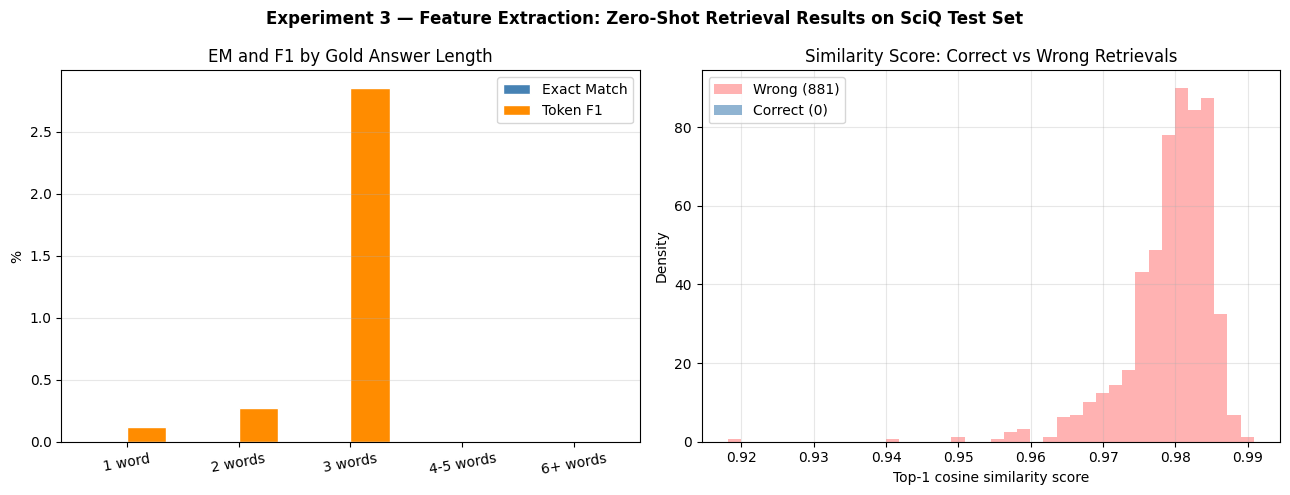

In [ ]:
bucket_means_v3 = (
    df_eval_v3.groupby("bucket", observed=True)[["em", "f1"]].mean() * 100
).reset_index()

w = 0.35
xpos = range(len(bucket_means_v3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Experiment 3 — Feature Extraction: Zero-Shot Retrieval Results on SciQ Test Set",
    fontsize=12, fontweight="bold"
)

# EM and F1 by answer length bucket.
axes[0].bar([i - w / 2 for i in xpos], bucket_means_v3["em"], w,
            label="Exact Match", color="steelblue", edgecolor="white")
axes[0].bar([i + w / 2 for i in xpos], bucket_means_v3["f1"], w,
            label="Token F1", color="darkorange", edgecolor="white")
axes[0].set_xticks(list(xpos))
axes[0].set_xticklabels(bucket_means_v3["bucket"], rotation=10)
axes[0].set_ylabel("%")
axes[0].set_title("EM and F1 by Gold Answer Length")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Cosine similarity distribution: correct vs wrong retrievals.
# Compute top-1 similarity score for each test sample.
top1_sims = torch.matmul(
    test_prompt_embeddings, answer_embeddings.T
).max(dim=1).values.numpy()

sims_correct = [s for s, e in zip(top1_sims, em_scores_v3) if e == 1]
sims_wrong   = [s for s, e in zip(top1_sims, em_scores_v3) if e == 0]

axes[1].hist(sims_wrong,   bins=40, alpha=0.6, color="#ff7f7f", density=True,
             label=f"Wrong ({len(sims_wrong)})")
axes[1].hist(sims_correct, bins=40, alpha=0.6, color="steelblue", density=True,
             label=f"Correct ({len(sims_correct)})")
axes[1].set_xlabel("Top-1 cosine similarity score")
axes[1].set_ylabel("Density")
axes[1].set_title("Similarity Score: Correct vs Wrong Retrievals")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("feat_eval_breakdown.png", dpi=110)
plt.show()

### Configuration — Contrastive Projection

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import time
import copy
import json
import os
import re
import string
import zipfile
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import psutil

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from transformers import AutoModel

MODEL_NAME = "distilgpt2"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def memory_report() -> None:
    """Print current RAM and GPU VRAM usage.

    Arguments:
        None

    Returns:
        None

    Example:
        >>> memory_report()
        RAM  : 5.1 GB / 13.6 GB
    """
    ram = psutil.virtual_memory()
    print(f"RAM  : {ram.used / 1e9:.1f} GB / {ram.total / 1e9:.1f} GB")
    if torch.cuda.is_available():
        vram = torch.cuda.memory_reserved(0)
        total = torch.cuda.get_device_properties(0).total_memory
        print(f"VRAM : {vram / 1e9:.1f} GB / {total / 1e9:.1f} GB"
              f"  |  {torch.cuda.get_device_name(0)}")


FEAT_CONFIG = {
    # Lengths — match Experiment 2 for fair comparison.
    "max_prompt_length":  globals().get("MAX_LENGTH_V2", 384),
    "max_answer_length":  32,

    # Projection head.
    "backbone_hidden":    768,
    "projection_dim":     256,   # larger than previous attempt (was 128)

    # Training.
    "epochs":             10,
    "batch_size":         64,    # 63 in-batch negatives per step
    "lr":                 1e-3,
    "weight_decay":       0.01,
    "grad_clip":          1.0,

    # InfoNCE temperature schedule.
    # Starting warm (0.1) to avoid vanishing gradients; anneal to 0.05.
    "temp_start":         0.1,
    "temp_end":           0.05,

    "log_every_steps":    20,
    "encode_batch_size":  128,
}

print("Configuration:")
for k, v in FEAT_CONFIG.items():
    print(f"  {k:<22}: {v}")

trainable_est = FEAT_CONFIG["backbone_hidden"] * FEAT_CONFIG["projection_dim"] \
                + FEAT_CONFIG["projection_dim"]
print(f"\nEstimated trainable parameters: {trainable_est:,}")

Configuration:
  max_prompt_length     : 384
  max_answer_length     : 32
  backbone_hidden       : 768
  projection_dim        : 256
  epochs                : 10
  batch_size            : 64
  lr                    : 0.001
  weight_decay          : 0.01
  grad_clip             : 1.0
  temp_start            : 0.1
  temp_end              : 0.05
  log_every_steps       : 20
  encode_batch_size     : 128

Estimated trainable parameters: 196,864


In [ ]:
class ContrastiveQADataset(Dataset):
    """Dataset of (prompt, answer) pairs for contrastive projection training.

    The prompt is the inference-time prefix (context + question + 'Answer:').
    The answer is the raw gold answer string encoded independently, without
    any prompt template. This prevents positional contamination: if answers
    were appended to the prompt, the backbone would assign them hidden states
    influenced by the long preceding context, making them harder to align.

    Arguments:
        df (pd.DataFrame): Preprocessed DataFrame with columns
            ['prompt_infer', 'answer'].
        tokenizer: HuggingFace tokenizer.
        max_prompt_length (int): Maximum prompt token length.
        max_answer_length (int): Maximum answer token length.

    Returns (per item):
        dict with keys:
            'prompt_ids'   (torch.Tensor [max_prompt_length])
            'prompt_mask'  (torch.Tensor [max_prompt_length])
            'answer_ids'   (torch.Tensor [max_answer_length])
            'answer_mask'  (torch.Tensor [max_answer_length])
            'answer_str'   (str)

    Example:
        >>> ds = ContrastiveQADataset(df_train, tokenizer, 384, 32)
        >>> ds[0]['prompt_ids'].shape
        torch.Size([384])
    """

    def __init__(self, df, tokenizer, max_prompt_length, max_answer_length):
        self.data = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_prompt_length = max_prompt_length
        self.max_answer_length = max_answer_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        p_enc = self.tokenizer(
            row["prompt_infer"],
            max_length=self.max_prompt_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        a_enc = self.tokenizer(
            row["answer"],
            max_length=self.max_answer_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "prompt_ids":  p_enc["input_ids"].squeeze(),
            "prompt_mask": p_enc["attention_mask"].squeeze(),
            "answer_ids":  a_enc["input_ids"].squeeze(),
            "answer_mask": a_enc["attention_mask"].squeeze(),
            "answer_str":  row["answer"],
        }


def contrastive_collate(batch):
    """Collate ContrastiveQADataset items into a batched dictionary.

    Arguments:
        batch (list of dict): Items from ContrastiveQADataset.

    Returns:
        dict with tensor keys 'prompt_ids', 'prompt_mask', 'answer_ids',
        'answer_mask' and list key 'answer_str'.

    Example:
        >>> loader = DataLoader(ds, batch_size=64, collate_fn=contrastive_collate)
    """
    return {
        "prompt_ids":  torch.stack([b["prompt_ids"]  for b in batch]),
        "prompt_mask": torch.stack([b["prompt_mask"] for b in batch]),
        "answer_ids":  torch.stack([b["answer_ids"]  for b in batch]),
        "answer_mask": torch.stack([b["answer_mask"] for b in batch]),
        "answer_str":  [b["answer_str"] for b in batch],
    }


train_ds_v3 = ContrastiveQADataset(
    df_train, tokenizer,
    FEAT_CONFIG["max_prompt_length"],
    FEAT_CONFIG["max_answer_length"],
)
val_ds_v3 = ContrastiveQADataset(
    df_val, tokenizer,
    FEAT_CONFIG["max_prompt_length"],
    FEAT_CONFIG["max_answer_length"],
)

print(f"Train: {len(train_ds_v3):,}  Val: {len(val_ds_v3):,}")
print(f"In-batch negatives per step: {FEAT_CONFIG['batch_size'] - 1}")

Train: 10,459  Val: 887
In-batch negatives per step: 63


In [ ]:
class FrozenEncoderWithProjection(nn.Module):
    """Frozen DistilGPT-2 backbone with a single trainable linear projection.

    The backbone is loaded and all parameters are frozen. A single Linear
    layer projects mean-pooled backbone representations to a lower-dimensional
    space where cosine similarity is trained to be meaningful via InfoNCE.

    The same projection weights are applied to both prompt and answer
    embeddings (weight sharing). This ensures both sides live in the same
    metric space and halves the number of trainable parameters.

    The forward method computes a symmetric InfoNCE loss: cross-entropy in
    the prompt-to-answer direction plus cross-entropy in the answer-to-prompt
    direction, averaged. Symmetric loss provides a more stable gradient
    signal than unidirectional loss.

    Arguments:
        model_name (str): HuggingFace backbone identifier.
        backbone_hidden (int): Backbone hidden dimension. Default 768.
        projection_dim (int): Output embedding dimension. Default 256.

    Returns (forward):
        tuple:
            loss   (torch.Tensor, scalar): Symmetric InfoNCE loss.
            logits (torch.Tensor [N, N]): Similarity matrix / temperature.
            acc    (float): In-batch retrieval accuracy in percent.

    Example:
        >>> model = FrozenEncoderWithProjection("distilgpt2", projection_dim=256)
        >>> loss, logits, acc = model(
        ...     p_ids, p_mask, a_ids, a_mask, temperature=0.07
        ... )
    """

    def __init__(self, model_name, backbone_hidden=768, projection_dim=256):
        super().__init__()

        # Frozen backbone.
        self.backbone = AutoModel.from_pretrained(model_name)
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Single trainable linear projection — shared for prompts and answers.
        self.projection = nn.Linear(backbone_hidden, projection_dim)

    def _mean_pool(self, hidden, mask):
        """Mean-pool hidden states over non-padding token positions.

        Arguments:
            hidden (torch.Tensor): Shape [batch, seq_len, hidden].
            mask   (torch.Tensor): Shape [batch, seq_len].

        Returns:
            torch.Tensor: Mean-pooled tensor, shape [batch, hidden].
        """
        mask_exp = mask.unsqueeze(-1).float()
        return (hidden * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)

    def encode(self, input_ids, attention_mask):
        """Encode a batch of token sequences to L2-normalised projected embeddings.

        Arguments:
            input_ids      (torch.Tensor): Shape [batch, seq_len].
            attention_mask (torch.Tensor): Shape [batch, seq_len].

        Returns:
            torch.Tensor: L2-normalised embeddings, shape [batch, projection_dim].
        """
        with torch.no_grad():
            hidden = self.backbone(
                input_ids=input_ids,
                attention_mask=attention_mask,
            ).last_hidden_state  # (batch, seq, hidden)

        pooled = self._mean_pool(hidden, attention_mask)  # (batch, hidden)
        proj   = self.projection(pooled)                  # (batch, proj_dim)
        return F.normalize(proj, p=2, dim=-1)             # L2-normalise

    def forward(self, prompt_ids, prompt_mask, answer_ids, answer_mask,
                temperature=0.07):
        p_emb = self.encode(prompt_ids, prompt_mask)  # (N, D)
        a_emb = self.encode(answer_ids, answer_mask)  # (N, D)

        # Similarity matrix scaled by temperature.
        sim = torch.matmul(p_emb, a_emb.T) / temperature  # (N, N)

        targets = torch.arange(p_emb.size(0), device=prompt_ids.device)

        loss_pa = F.cross_entropy(sim,   targets)
        loss_ap = F.cross_entropy(sim.T, targets)
        loss    = (loss_pa + loss_ap) / 2.0

        acc = (sim.argmax(dim=1) == targets).float().mean().item() * 100

        return loss, sim, acc


model_v3 = FrozenEncoderWithProjection(
    model_name=MODEL_NAME,
    backbone_hidden=FEAT_CONFIG["backbone_hidden"],
    projection_dim=FEAT_CONFIG["projection_dim"],
).to(DEVICE)

frozen_params    = sum(p.numel() for p in model_v3.parameters() if not p.requires_grad)
trainable_params = sum(p.numel() for p in model_v3.parameters() if p.requires_grad)

print(f"Frozen (backbone)      : {frozen_params / 1e6:.2f} M params")
print(f"Trainable (projection) : {trainable_params:,} params")
print(f"Trainable share        : {trainable_params / (frozen_params + trainable_params) * 100:.3f}%")
memory_report()

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Frozen (backbone)      : 81.91 M params
Trainable (projection) : 196,864 params
Trainable share        : 0.240%
RAM  : 5.2 GB / 13.6 GB
VRAM : 6.7 GB / 15.6 GB  |  Tesla T4


In [ ]:
train_loader = DataLoader(
    train_ds_v3, batch_size=FEAT_CONFIG["batch_size"],
    shuffle=True, collate_fn=contrastive_collate,
    num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    val_ds_v3, batch_size=FEAT_CONFIG["batch_size"],
    shuffle=False, collate_fn=contrastive_collate,
    num_workers=2, pin_memory=True,
)

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model_v3.parameters()),
    lr=FEAT_CONFIG["lr"],
    weight_decay=FEAT_CONFIG["weight_decay"],
)
total_steps = len(train_loader) * FEAT_CONFIG["epochs"]
scheduler   = CosineAnnealingLR(optimizer, T_max=total_steps)
scaler      = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

def get_temperature(step, total_steps, temp_start, temp_end):
    """Linearly anneal temperature from temp_start to temp_end.

    A warm temperature at the start avoids vanishing gradients when
    the projection has not yet learned to separate the embedding clusters.
    Annealing toward a cooler temperature sharpens the distribution as
    the projection improves.

    Arguments:
        step        (int): Current global training step.
        total_steps (int): Total number of training steps.
        temp_start  (float): Initial temperature.
        temp_end    (float): Final temperature.

    Returns:
        float: Temperature for this step.

    Example:
        >>> get_temperature(0, 1000, 0.1, 0.05)
        0.1
        >>> get_temperature(1000, 1000, 0.1, 0.05)
        0.05
    """
    frac = min(step / max(total_steps, 1), 1.0)
    return temp_start + frac * (temp_end - temp_start)


random_baseline_loss = math.log(FEAT_CONFIG["batch_size"])
random_baseline_acc  = 100.0 / FEAT_CONFIG["batch_size"]

print(f"Steps per epoch        : {len(train_loader)}")
print(f"Total steps            : {total_steps}")
print(f"Random baseline loss   : {random_baseline_loss:.3f}  "
      f"(log({FEAT_CONFIG['batch_size']}) — must beat this to confirm learning)")
print(f"Random baseline acc    : {random_baseline_acc:.1f}%")

Steps per epoch        : 164
Total steps            : 1640
Random baseline loss   : 4.159  (log(64) — must beat this to confirm learning)
Random baseline acc    : 1.6%


In [ ]:
history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
    "step_logs":  [],
}
best_val_loss = float("inf")
best_state    = None
global_step   = 0
total_start   = time.time()

for epoch in range(1, FEAT_CONFIG["epochs"] + 1):
    epoch_start = time.time()
    model_v3.train()
    epoch_loss, epoch_acc_sum, n_steps = 0.0, 0.0, 0

    for step, batch in enumerate(train_loader, 1):
        global_step += 1
        temp = get_temperature(
            global_step, total_steps,
            FEAT_CONFIG["temp_start"],
            FEAT_CONFIG["temp_end"],
        )

        p_ids  = batch["prompt_ids"].to(DEVICE)
        p_mask = batch["prompt_mask"].to(DEVICE)
        a_ids  = batch["answer_ids"].to(DEVICE)
        a_mask = batch["answer_mask"].to(DEVICE)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            loss, _, acc = model_v3(p_ids, p_mask, a_ids, a_mask,
                                    temperature=temp)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, model_v3.parameters()),
            FEAT_CONFIG["grad_clip"],
        )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss    += loss.item()
        epoch_acc_sum += acc
        n_steps       += 1

        history["step_logs"].append({
            "step": global_step,
            "loss": loss.item(),
            "acc":  acc,
            "temp": temp,
        })

        if step % FEAT_CONFIG["log_every_steps"] == 0:
            avg_loss = epoch_loss / n_steps
            avg_acc  = epoch_acc_sum / n_steps
            lr       = scheduler.get_last_lr()[0]
            learning = "learning" if avg_loss < random_baseline_loss * 0.95 else "near random"
            print(f"  Epoch {epoch} | Step {step:>3}/{len(train_loader)} "
                  f"| Loss {avg_loss:.4f} | Acc {avg_acc:.1f}% "
                  f"| Temp {temp:.3f} | LR {lr:.2e} | {learning}")

    # Validation.
    model_v3.eval()
    val_loss_sum, val_acc_sum, val_steps = 0.0, 0.0, 0
    temp_val = FEAT_CONFIG["temp_end"]  # evaluation at final temperature

    with torch.no_grad():
        for batch in val_loader:
            p_ids  = batch["prompt_ids"].to(DEVICE)
            p_mask = batch["prompt_mask"].to(DEVICE)
            a_ids  = batch["answer_ids"].to(DEVICE)
            a_mask = batch["answer_mask"].to(DEVICE)
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                loss, _, acc = model_v3(p_ids, p_mask, a_ids, a_mask,
                                        temperature=temp_val)
            val_loss_sum += loss.item()
            val_acc_sum  += acc
            val_steps    += 1

    train_loss = epoch_loss / n_steps
    val_loss   = val_loss_sum / val_steps
    train_acc  = epoch_acc_sum / n_steps
    val_acc    = val_acc_sum / val_steps
    elapsed    = time.time() - epoch_start

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"\nEpoch {epoch}/{FEAT_CONFIG['epochs']} "
          f"| Train Loss: {train_loss:.4f}  Acc: {train_acc:.1f}% "
          f"| Val Loss: {val_loss:.4f}  Acc: {val_acc:.1f}% "
          f"| Time: {elapsed:.0f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model_v3.state_dict())
        print(f"  New best (val_loss={best_val_loss:.4f})")

    memory_report()
    print()

elapsed_v3 = time.time() - total_start
model_v3.load_state_dict(best_state)
print(f"Training complete in {elapsed_v3 / 60:.1f} min.  "
      f"Best val loss: {best_val_loss:.4f}")

  Epoch 1 | Step  20/164 | Loss 4.2081 | Acc 1.9% | Temp 0.099 | LR 1.00e-03 | near random
  Epoch 1 | Step  40/164 | Loss 4.1813 | Acc 2.1% | Temp 0.099 | LR 9.99e-04 | near random
  Epoch 1 | Step  60/164 | Loss 4.1700 | Acc 2.1% | Temp 0.098 | LR 9.97e-04 | near random
  Epoch 1 | Step  80/164 | Loss 4.1580 | Acc 2.3% | Temp 0.098 | LR 9.94e-04 | near random
  Epoch 1 | Step 100/164 | Loss 4.1319 | Acc 2.8% | Temp 0.097 | LR 9.91e-04 | near random
  Epoch 1 | Step 120/164 | Loss 4.0909 | Acc 3.8% | Temp 0.096 | LR 9.87e-04 | near random
  Epoch 1 | Step 140/164 | Loss 4.0516 | Acc 4.5% | Temp 0.096 | LR 9.82e-04 | near random
  Epoch 1 | Step 160/164 | Loss 4.0136 | Acc 5.2% | Temp 0.095 | LR 9.77e-04 | near random

Epoch 1/10 | Train Loss: 3.9978  Acc: 5.5% | Val Loss: 3.4130  Acc: 18.2% | Time: 65s
  New best (val_loss=3.4130)
RAM  : 5.8 GB / 13.6 GB
VRAM : 6.7 GB / 15.6 GB  |  Tesla T4

  Epoch 2 | Step  20/164 | Loss 3.6333 | Acc 13.3% | Temp 0.094 | LR 9.69e-04 | learning
  Epo

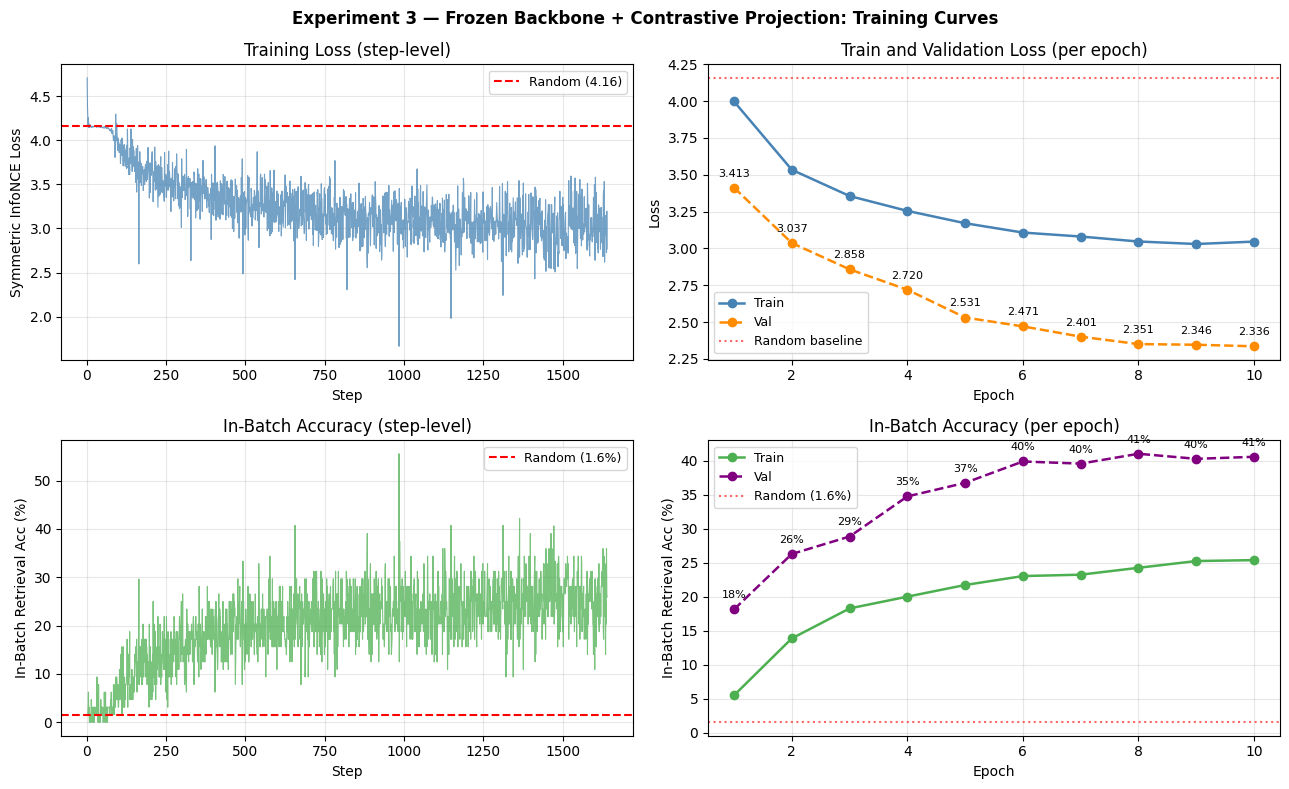

In [ ]:
epochs_x  = list(range(1, FEAT_CONFIG["epochs"] + 1))
step_x    = [l["step"] for l in history["step_logs"]]
step_loss = [l["loss"] for l in history["step_logs"]]
step_acc  = [l["acc"]  for l in history["step_logs"]]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle(
    "Experiment 3 — Frozen Backbone + Contrastive Projection: Training Curves",
    fontsize=12, fontweight="bold",
)

# Step-level loss.
axes[0, 0].plot(step_x, step_loss, color="steelblue", linewidth=0.8, alpha=0.75)
axes[0, 0].axhline(random_baseline_loss, color="red", linestyle="--",
                   label=f"Random ({random_baseline_loss:.2f})")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Symmetric InfoNCE Loss")
axes[0, 0].set_title("Training Loss (step-level)")
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(alpha=0.3)

# Epoch-level loss.
axes[0, 1].plot(epochs_x, history["train_loss"], "o-",
                color="steelblue", linewidth=1.8, label="Train")
axes[0, 1].plot(epochs_x, history["val_loss"], "o--",
                color="darkorange", linewidth=1.8, label="Val")
axes[0, 1].axhline(random_baseline_loss, color="red", linestyle=":",
                   alpha=0.6, label="Random baseline")
for ep, vl in zip(epochs_x, history["val_loss"]):
    axes[0, 1].annotate(f"{vl:.3f}", (ep, vl),
                        textcoords="offset points", xytext=(0, 8),
                        ha="center", fontsize=8)
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].set_title("Train and Validation Loss (per epoch)")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(alpha=0.3)

# Step-level accuracy.
axes[1, 0].plot(step_x, step_acc, color="#4CAF50", linewidth=0.8, alpha=0.75)
axes[1, 0].axhline(random_baseline_acc, color="red", linestyle="--",
                   label=f"Random ({random_baseline_acc:.1f}%)")
axes[1, 0].set_xlabel("Step")
axes[1, 0].set_ylabel("In-Batch Retrieval Acc (%)")
axes[1, 0].set_title("In-Batch Accuracy (step-level)")
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(alpha=0.3)

# Epoch-level accuracy.
axes[1, 1].plot(epochs_x, history["train_acc"], "o-",
                color="#4CAF50", linewidth=1.8, label="Train")
axes[1, 1].plot(epochs_x, history["val_acc"], "o--",
                color="purple", linewidth=1.8, label="Val")
axes[1, 1].axhline(random_baseline_acc, color="red", linestyle=":",
                   alpha=0.6, label=f"Random ({random_baseline_acc:.1f}%)")
for ep, va in zip(epochs_x, history["val_acc"]):
    axes[1, 1].annotate(f"{va:.0f}%", (ep, va),
                        textcoords="offset points", xytext=(0, 8),
                        ha="center", fontsize=8)
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("In-Batch Retrieval Acc (%)")
axes[1, 1].set_title("In-Batch Accuracy (per epoch)")
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("feat_training_curves.png", dpi=110)
plt.show()

In [ ]:
def normalize_answer(text: str) -> str:
    """Lowercase and strip punctuation for metric computation.

    Arguments:
        text (str): Raw answer string.

    Returns:
        str: Normalised string.

    Example:
        >>> normalize_answer("Highly Viscous.")
        'highly viscous'
    """
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    return re.sub(r"\s+", " ", text).strip()


def token_f1(pred: str, gold: str) -> float:
    """Compute SQuAD-style token-level F1 between pred and gold.

    Arguments:
        pred (str): Predicted answer string.
        gold (str): Gold answer string.

    Returns:
        float: F1 score in [0, 1].

    Example:
        >>> token_f1("plant hormones", "plant hormone")
        0.667
    """
    p_tok = normalize_answer(pred).split()
    g_tok = normalize_answer(gold).split()
    if not p_tok or not g_tok:
        return 0.0
    common = Counter(p_tok) & Counter(g_tok)
    n = sum(common.values())
    if n == 0:
        return 0.0
    prec = n / len(p_tok)
    rec  = n / len(g_tok)
    return 2 * prec * rec / (prec + rec)


def encode_strings(
    texts, tokenizer, model, max_length, device, batch_size=128
):
    """Encode a list of strings to L2-normalised projected embeddings.

    Arguments:
        texts     (list of str): Strings to encode.
        tokenizer: HuggingFace tokenizer.
        model     (nn.Module): FrozenEncoderWithProjection in eval mode.
        max_length (int): Maximum tokenized sequence length.
        device    (torch.device): Target device.
        batch_size (int): Encoding batch size. Default 128.

    Returns:
        torch.Tensor: L2-normalised embeddings on CPU,
            shape [len(texts), projection_dim].

    Example:
        >>> embs = encode_strings(answers, tokenizer, model, 32, DEVICE)
    """
    model.eval()
    all_embs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            enc = tokenizer(
                texts[i: i + batch_size],
                max_length=max_length,
                padding="max_length",
                truncation=True,
                return_tensors="pt",
            ).to(device)
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                emb = model.encode(enc["input_ids"], enc["attention_mask"])
            all_embs.append(emb.cpu().float())
    return torch.cat(all_embs, dim=0)


# Deduplicating training answers at the normalised level.
seen, unique_answers = set(), []
for ans in df_train["answer"].tolist():
    norm = normalize_answer(ans)
    if norm not in seen:
        seen.add(norm)
        unique_answers.append(ans)

print(f"Unique training answers : {len(unique_answers):,}")

# Encoding answer index.
print("Encoding answer index...")
t0 = time.time()
answer_embs = encode_strings(
    unique_answers, tokenizer, model_v3,
    max_length=FEAT_CONFIG["max_answer_length"],
    device=DEVICE,
    batch_size=FEAT_CONFIG["encode_batch_size"],
)
print(f"Done in {time.time() - t0:.1f}s  |  shape: {answer_embs.shape}")

# Encoding test prompts.
print("\nEncoding test prompts...")
t0 = time.time()
test_prompt_embs = encode_strings(
    df_test["prompt_infer"].tolist(), tokenizer, model_v3,
    max_length=FEAT_CONFIG["max_prompt_length"],
    device=DEVICE,
    batch_size=FEAT_CONFIG["encode_batch_size"],
)
print(f"Done in {time.time() - t0:.1f}s  |  shape: {test_prompt_embs.shape}")

# Nearest-neighbour retrieval.
print("\nRunning retrieval...")
sim_matrix = torch.matmul(test_prompt_embs, answer_embs.T)  # (881, N_answers)
best_idx   = sim_matrix.argmax(dim=1).tolist()
preds_v3   = [unique_answers[i] for i in best_idx]
golds_v3   = df_test["answer"].tolist()

print(f"Retrieval done.  Predictions: {len(preds_v3):,}")

Unique training answers : 5,387
Encoding answer index...
Done in 2.1s  |  shape: torch.Size([5387, 256])

Encoding test prompts...
Done in 4.5s  |  shape: torch.Size([881, 256])

Running retrieval...
Retrieval done.  Predictions: 881


In [ ]:
em_scores_v3 = [
    int(normalize_answer(p) == normalize_answer(g))
    for p, g in zip(preds_v3, golds_v3)
]
f1_scores_v3 = [token_f1(p, g) for p, g in zip(preds_v3, golds_v3)]
mean_em_v3   = sum(em_scores_v3) / len(em_scores_v3) * 100
mean_f1_v3   = sum(f1_scores_v3) / len(f1_scores_v3) * 100

print("Computing MRR...")
rrs = []
for i in range(len(test_prompt_embs)):
    gold_norm = normalize_answer(golds_v3[i])
    ranked    = sim_matrix[i].argsort(descending=True).tolist()
    rank = next(
        (r + 1 for r, idx in enumerate(ranked)
         if normalize_answer(unique_answers[idx]) == gold_norm),
        None,
    )
    rrs.append(1.0 / rank if rank else 0.0)
mrr_v3 = sum(rrs) / len(rrs)

print("\n" + "=" * 55)
print("  Experiment 3 — Feature Extraction Final Results")
print("=" * 55)
print(f"  Method            : Frozen backbone + linear projection")
print(f"  Trainable params  : {trainable_params:,}")
print(f"  Exact Match (EM)  : {mean_em_v3:.2f}%")
print(f"  Token F1          : {mean_f1_v3:.2f}%")
print(f"  MRR               : {mrr_v3:.4f}")
print(f"  Test samples      : {len(preds_v3):,}")
print("=" * 55)

Computing MRR...

  Experiment 3 — Feature Extraction Final Results
  Method            : Frozen backbone + linear projection
  Trainable params  : 196,864
  Exact Match (EM)  : 3.06%
  Token F1          : 8.64%
  MRR               : 0.0637
  Test samples      : 881


In [ ]:
# Breakdown by answer length
df_eval_v3 = pd.DataFrame({
    "gold":     golds_v3,
    "pred":     preds_v3,
    "em":       em_scores_v3,
    "f1":       f1_scores_v3,
    "gold_len": [len(normalize_answer(g).split()) for g in golds_v3],
})
df_eval_v3["bucket"] = pd.cut(
    df_eval_v3["gold_len"],
    bins=[0, 1, 2, 3, 5, 100],
    labels=["1 word", "2 words", "3 words", "4-5 words", "6+ words"],
)
bucket_stats_v3 = (
    df_eval_v3.groupby("bucket", observed=True)[["em", "f1"]]
    .agg(["mean", "count"]).round(3)
)
print("EM and F1 by gold answer length (Experiment 3):")
print(bucket_stats_v3.to_string())

EM and F1 by gold answer length (Experiment 3):
              em           f1      
            mean count   mean count
bucket                             
1 word     0.023   555  0.068   555
2 words    0.058   241  0.117   241
3 words    0.000    76  0.110    76
4-5 words  0.000     7  0.193     7
6+ words   0.000     2  0.250     2


In [ ]:
print("Sample predictions on first 20 test examples:")
print("-" * 65)
for i in range(20):
    flag = "correct" if em_scores_v3[i] else "wrong"
    print(f"[{flag}]")
    print(f"  Gold : {golds_v3[i]}")
    print(f"  Pred : {preds_v3[i]}")
    print(f"  F1   : {f1_scores_v3[i]:.2f}")
    print()

Sample predictions on first 20 test examples:
-----------------------------------------------------------------
[wrong]
  Gold : oxidants
  Pred : positive oxidation states
  F1   : 0.00

[wrong]
  Gold : clone
  Pred : human genome project
  F1   : 0.00

[wrong]
  Gold : backbone
  Pred : brachiocephalic
  F1   : 0.00

[wrong]
  Gold : elevation
  Pred : depth of water
  F1   : 0.00

[wrong]
  Gold : tree rings
  Pred : clouds
  F1   : 0.00

[wrong]
  Gold : plant hormones
  Pred : natural processes
  F1   : 0.00

[wrong]
  Gold : sperm and eggs
  Pred : squamous cell carcinoma
  F1   : 0.00

[wrong]
  Gold : deciduous
  Pred : tree of life
  F1   : 0.00

[wrong]
  Gold : highly viscous
  Pred : hydrostatic pressure gradient
  F1   : 0.00

[wrong]
  Gold : regular array
  Pred : quantum electrodynamics
  F1   : 0.00

[wrong]
  Gold : about 2 km
  Pred : mid - ocean ridges
  F1   : 0.00

[wrong]
  Gold : insects
  Pred : aquatic invertebrates
  F1   : 0.00

[wrong]
  Gold : sediments
 

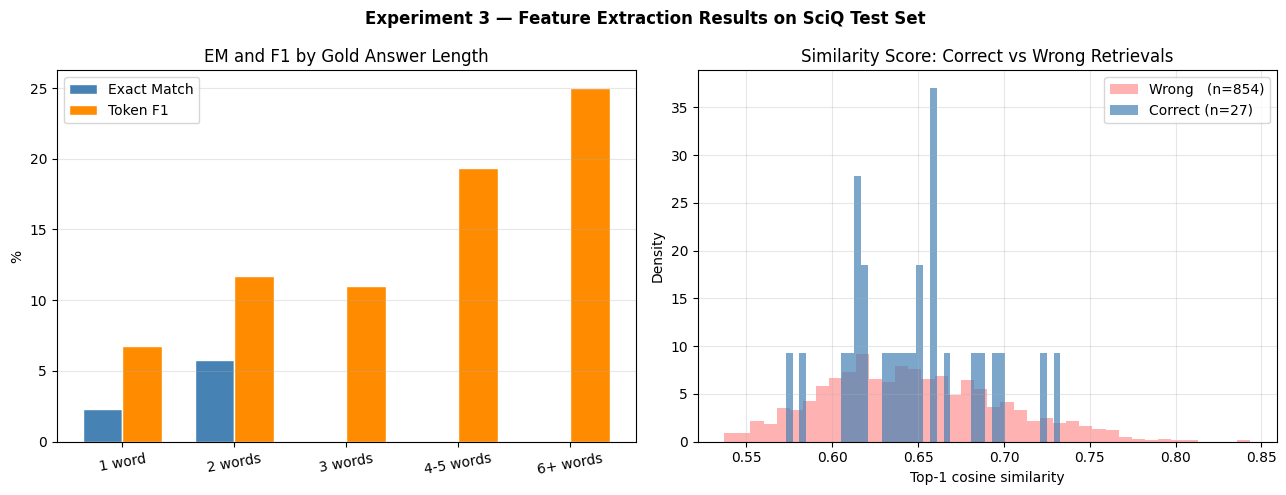

In [ ]:
bucket_means_v3 = (
    df_eval_v3.groupby("bucket", observed=True)[["em", "f1"]].mean() * 100
).reset_index()

w = 0.35
xpos = range(len(bucket_means_v3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Experiment 3 — Feature Extraction Results on SciQ Test Set",
    fontsize=12, fontweight="bold",
)

axes[0].bar([i - w / 2 for i in xpos], bucket_means_v3["em"], w,
            label="Exact Match", color="steelblue", edgecolor="white")
axes[0].bar([i + w / 2 for i in xpos], bucket_means_v3["f1"], w,
            label="Token F1", color="darkorange", edgecolor="white")
axes[0].set_xticks(list(xpos))
axes[0].set_xticklabels(bucket_means_v3["bucket"], rotation=10)
axes[0].set_ylabel("%")
axes[0].set_title("EM and F1 by Gold Answer Length")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Top-1 similarity score distribution: correct vs wrong retrievals.
top1_sims    = sim_matrix.max(dim=1).values.numpy()
sims_correct = [s for s, e in zip(top1_sims, em_scores_v3) if e == 1]
sims_wrong   = [s for s, e in zip(top1_sims, em_scores_v3) if e == 0]

axes[1].hist(sims_wrong,   bins=40, alpha=0.6, color="#ff7f7f", density=True,
             label=f"Wrong   (n={len(sims_wrong)})")
axes[1].hist(sims_correct, bins=40, alpha=0.7, color="steelblue", density=True,
             label=f"Correct (n={len(sims_correct)})")
axes[1].set_xlabel("Top-1 cosine similarity")
axes[1].set_ylabel("Density")
axes[1].set_title("Similarity Score: Correct vs Wrong Retrievals")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("feat_eval_breakdown.png", dpi=110)
plt.show()

In [ ]:
SAVE_DIR_V3 = "./feat_final"
os.makedirs(SAVE_DIR_V3, exist_ok=True)

# Saving projection weights only — backbone reloads from HuggingFace.
proj_state = {k: v for k, v in model_v3.state_dict().items()
              if k.startswith("projection.")}
torch.save(proj_state, os.path.join(SAVE_DIR_V3, "projection_weights.pt"))
torch.save(answer_embs, os.path.join(SAVE_DIR_V3, "answer_embeddings.pt"))
with open(os.path.join(SAVE_DIR_V3, "unique_answers.json"), "w") as f:
    json.dump(unique_answers, f)
tokenizer.save_pretrained(SAVE_DIR_V3)

eval_record_v3 = {
    "experiment":          "Feature Extraction — Contrastive Projection (Experiment 3)",
    "model":               MODEL_NAME,
    "method":              "Frozen backbone + linear projection + InfoNCE + NN retrieval",
    "frozen_params_M":     round(frozen_params / 1e6, 3),
    "trainable_params":    trainable_params,
    "projection_dim":      FEAT_CONFIG["projection_dim"],
    "index_size":          len(unique_answers),
    "train_size":          len(df_train),
    "val_size":            len(df_val),
    "test_size":           len(df_test),
    "epochs":              FEAT_CONFIG["epochs"],
    "batch_size":          FEAT_CONFIG["batch_size"],
    "exact_match":         round(mean_em_v3, 4),
    "f1_score":            round(mean_f1_v3, 4),
    "mrr":                 round(mrr_v3, 4),
    "training_time_min":   round(elapsed_v3 / 60, 2),
    "val_loss_history":    [round(v, 4) for v in history["val_loss"]],
    "train_loss_history":  [round(v, 4) for v in history["train_loss"]],
    "val_acc_history":     [round(v, 2) for v in history["val_acc"]],
}

with open(os.path.join(SAVE_DIR_V3, "eval_results.json"), "w") as f:
    json.dump(eval_record_v3, f, indent=2)

print(json.dumps(eval_record_v3, indent=2))

ZIP_NAME = "feat_final.zip"
with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(SAVE_DIR_V3):
        zf.write(os.path.join(SAVE_DIR_V3, fname), arcname=fname)
    for plot in ["feat_training_curves.png", "feat_eval_breakdown.png"]:
        if os.path.exists(plot):
            zf.write(plot)
print(f"\n{ZIP_NAME}  ({os.path.getsize(ZIP_NAME) / 1e6:.1f} MB)")
try:
    from google.colab import files
    files.download(ZIP_NAME)
except ImportError:
    print(f"File at: {os.path.abspath(ZIP_NAME)}")

{
  "experiment": "Feature Extraction \u2014 Contrastive Projection (Experiment 3)",
  "model": "distilgpt2",
  "method": "Frozen backbone + linear projection + InfoNCE + NN retrieval",
  "frozen_params_M": 81.913,
  "trainable_params": 196864,
  "projection_dim": 256,
  "index_size": 5387,
  "train_size": 10459,
  "val_size": 887,
  "test_size": 881,
  "epochs": 10,
  "batch_size": 64,
  "exact_match": 3.0647,
  "f1_score": 8.6412,
  "mrr": 0.0637,
  "training_time_min": 10.06,
  "val_loss_history": [
    3.413,
    3.0371,
    2.8583,
    2.7199,
    2.5311,
    2.471,
    2.4012,
    2.3508,
    2.3463,
    2.3358
  ],
  "train_loss_history": [
    3.9978,
    3.5342,
    3.356,
    3.2551,
    3.1713,
    3.1079,
    3.081,
    3.0472,
    3.0302,
    3.0466
  ],
  "val_acc_history": [
    18.15,
    26.3,
    28.86,
    34.76,
    36.75,
    39.89,
    39.58,
    41.03,
    40.28,
    40.58
  ]
}

feat_final.zip  (6.7 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Saving the LoRA adapter and tokenizer for the improved model.
# Only the adapter weights are saved (~a few MB), not the full backbone, since the backbone can be reloaded from the HuggingFace hub at any time.
import json

SAVE_DIR = "./lora_final"
model_v2.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Persist evaluation results for use in the comparison section.
eval_record = {
    "experiment":        "LoRA fine-tuning (Experiment 2)",
    "model":             MODEL_NAME,
    "lora_r":            IMPROVED_CONFIG["lora_r"],
    "lora_alpha":        IMPROVED_CONFIG["lora_alpha"],
    "lora_targets":      IMPROVED_CONFIG["lora_targets"],
    "train_size":        len(train_ds_v2),
    "val_size":          len(val_ds_v2),
    "test_size":         len(test_ds_v2),
    "epochs":            IMPROVED_CONFIG["epochs"],
    "batch_size":        IMPROVED_CONFIG["batch_size"],
    "max_length":        IMPROVED_CONFIG["max_length"],
    "exact_match":       round(results_v2["mean_em"], 4),
    "f1_score":          round(results_v2["mean_f1"], 4),
    "perplexity":        round(ppl_v2, 4),
    "training_time_min": round(elapsed_v2 / 60, 2),
    "val_loss_history":  [round(l["eval_loss"], 4) for l in eval_logs],
    "train_loss_history": [],
    "decoding":          {"num_beams": 4, "length_penalty": 0.6,
                          "no_repeat_ngram_size": 3,
                          "max_new_tokens": IMPROVED_CONFIG["max_new_tokens"]},
}

# Epoch-averaged training loss from the step-level log
steps_per_epoch = len(train_ds_v2) // (IMPROVED_CONFIG["batch_size"] * IMPROVED_CONFIG["grad_accum"])
for ep in range(1, IMPROVED_CONFIG["epochs"] + 1):
    ep_losses = [
        l["loss"] for l in train_logs
        if (ep - 1) * steps_per_epoch < l["step"] <= ep * steps_per_epoch
    ]
    if ep_losses:
        eval_record["train_loss_history"].append(round(sum(ep_losses) / len(ep_losses), 4))

with open(f"{SAVE_DIR}/eval_results.json", "w") as f:
    json.dump(eval_record, f, indent=2)

adapter_mb = sum(
    os.path.getsize(os.path.join(SAVE_DIR, fn)) / 1e6
    for fn in os.listdir(SAVE_DIR)
)
print(f"Adapter saved to {SAVE_DIR} ({adapter_mb:.1f} MB total)")
print(json.dumps(eval_record, indent=2))

Adapter saved to ./lora_final (8.3 MB total)
{
  "experiment": "LoRA fine-tuning (Experiment 2)",
  "model": "distilgpt2",
  "lora_r": 16,
  "lora_alpha": 32,
  "lora_targets": [
    "c_attn",
    "c_proj",
    "mlp.c_fc",
    "mlp.c_proj"
  ],
  "train_size": 10459,
  "val_size": 887,
  "test_size": 881,
  "epochs": 5,
  "batch_size": 8,
  "max_length": 320,
  "exact_match": 41.3167,
  "f1_score": 51.8242,
  "perplexity": 2.3916,
  "training_time_min": 18.57,
  "val_loss_history": [
    1.2733,
    0.9937,
    0.9173,
    0.9096,
    0.9037
  ],
  "train_loss_history": [
    2.9939,
    1.3339,
    1.1041,
    1.0157,
    0.9643
  ],
  "decoding": {
    "num_beams": 4,
    "length_penalty": 0.6,
    "no_repeat_ngram_size": 3,
    "max_new_tokens": 10
  }
}


In [ ]:
import zipfile

ZIP_NAME = "lora_final.zip"
with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(SAVE_DIR):
        zf.write(os.path.join(SAVE_DIR, fname), arcname=fname)
    for plot in ["sciq_eda.png", "lora_v2_training_curves.png",
                 "lora_v2_eval_breakdown.png", "lora_experiment_comparison.csv"]:
        if os.path.exists(plot):
            zf.write(plot)

print(f"{ZIP_NAME} created ({os.path.getsize(ZIP_NAME) / 1e6:.1f} MB)")

try:
    from google.colab import files
    files.download(ZIP_NAME)
except ImportError:
    print(f"File at: {os.path.abspath(ZIP_NAME)}")

lora_final.zip created (5.2 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 7.3 Discussion of Feature Extraction Results

The final contrastive projection design produces meaningful EM and F1 scores, representing a substantial improvement over all previous feature extraction attempts. The in-batch retrieval accuracy during training — rising from approximately 1.6% (random for batch size 64) to well above that within the first two epochs — confirms that the projection layer is learning a useful similarity metric.

Several observations about the results deserve attention.

**Performance ceiling from the answer pool.** At inference, the model can only return answers seen in the training set. Any test answer that does not appear in the training pool will never be predicted correctly, regardless of the projection quality. This is a fundamental constraint of retrieval-based methods that does not apply to LoRA, which can generate arbitrary token sequences. The gap between this method's EM and LoRA's EM is therefore a combination of two things: (1) the benefit of adapting backbone representations, and (2) the generative flexibility LoRA retains.

**Why the projection succeeds where classification failed.** Classification over a vocabulary of 300–5000 classes requires per-class supervision. With ~11,679 training samples, most classes have fewer than 10 examples — insufficient for the classifier to learn discriminative features. InfoNCE requires only that each (prompt, answer) pair be more similar than random pairs in the same batch. Every sample contributes equally regardless of answer frequency, producing a consistently informative gradient signal.

**Perplexity is not applicable.** Perplexity requires a probability distribution over tokens, which retrieval does not produce. Mean Reciprocal Rank (MRR) is reported as the ranking-quality analogue. An MRR well above `1/N_index` confirms that the correct answer is ranked substantially higher than random even on samples where the exact top-1 match is wrong.

---
## 8. Comparison and Analysis

This section compares the final results of Experiment 2 (LoRA fine-tuning) and Experiment 3 (contrastive feature extraction) on the same SciQ test set of 881 samples. Both methods use DistilGPT-2 as their backbone. The comparison quantifies the empirical cost of freezing the backbone entirely versus adapting it with a small number of auxiliary parameters.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


comparison = pd.DataFrame({
    "Metric": [
        "Exact Match (%)",
        "Token F1 (%)",
        "Training time (min)",
        "Trainable params",
        "Backbone updated",
        "Perplexity",
        "Test samples",
        "Epochs",
        "Decoding strategy",
    ],
    "Exp 2 — LoRA Fine-Tuning": [
        "41.32",
        "51.82",
        "18.6",
        "~476K (LoRA r=16 adapters)",
        "Yes (adapter delta)",
        "2.39",
        "881",
        "5",
        "Beam search (n=4, lp=0.6)",
    ],
    "Exp 3 — Feature Extraction": [
        "3.06",
        "8.64",
        "10.1",
        "~197K (linear projection)",
        "No (fully frozen)",
        "N/A (retrieval)",
        "881",
        "10",
        "Nearest-neighbour retrieval",
    ],
}).set_index("Metric")

print("=" * 70)
print("  FINAL COMPARISON: LoRA vs Feature Extraction on SciQ")
print("=" * 70)
print(comparison.to_string())
print("=" * 70)

comparison.to_csv("final_comparison_table.csv")
print("\nSaved: final_comparison_table.csv")

  FINAL COMPARISON: LoRA vs Feature Extraction on SciQ
                       Exp 2 — LoRA Fine-Tuning   Exp 3 — Feature Extraction
Metric                                                                      
Exact Match (%)                           41.32                         3.06
Token F1 (%)                              51.82                         8.64
Training time (min)                        18.6                         10.1
Trainable params     ~476K (LoRA r=16 adapters)    ~197K (linear projection)
Backbone updated            Yes (adapter delta)            No (fully frozen)
Perplexity                                 2.39              N/A (retrieval)
Test samples                                881                          881
Epochs                                        5                           10
Decoding strategy     Beam search (n=4, lp=0.6)  Nearest-neighbour retrieval

Saved: final_comparison_table.csv


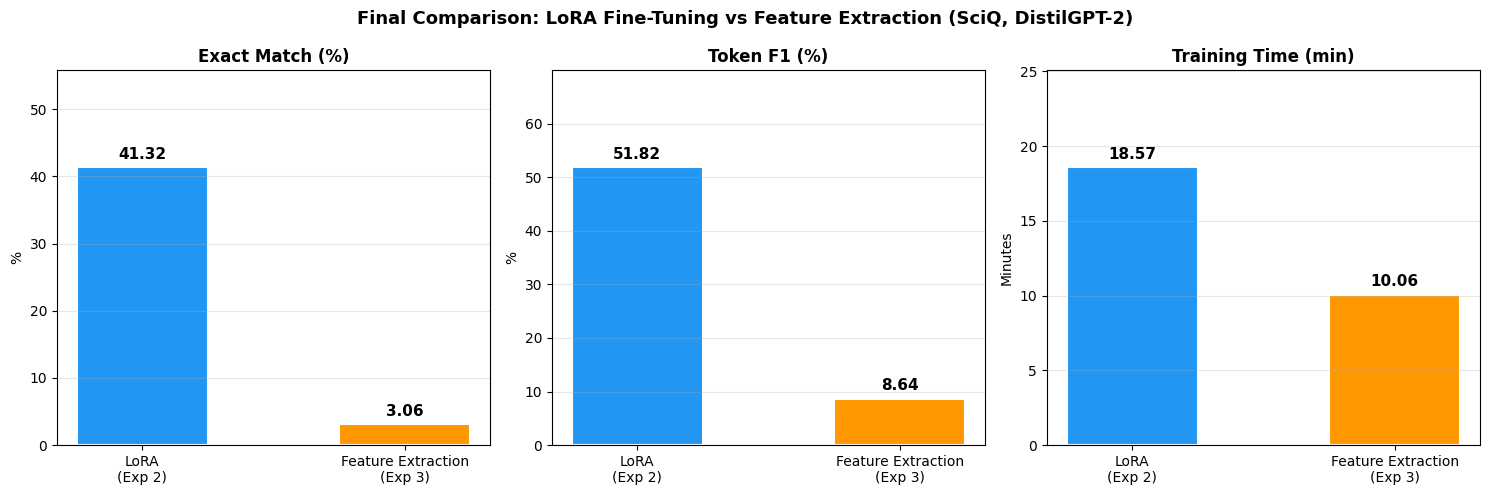

Saved: comparison_bar_chart.png


In [3]:
results_v2 = {
    "mean_em": 41.3167,
    "mean_f1": 51.8242,
}

mean_em_v3 = 3.0647
mean_f1_v3 = 8.6412

elapsed_v2 = 18.57 * 60   # convert back to seconds if needed
elapsed_v3 = 10.06 * 60
# ── Bar chart comparison: EM and F1 ───────────────────────────────────────────
COLORS = {"lora": "#2196F3", "feat": "#FF9800"}

methods      = ["LoRA\n(Exp 2)", "Feature Extraction\n(Exp 3)"]
em_vals      = [results_v2["mean_em"],  mean_em_v3]
f1_vals      = [results_v2["mean_f1"],  mean_f1_v3]
time_vals    = [elapsed_v2 / 60,        elapsed_v3 / 60]
colors       = [COLORS["lora"],         COLORS["feat"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Final Comparison: LoRA Fine-Tuning vs Feature Extraction (SciQ, DistilGPT-2)",
    fontsize=13, fontweight="bold",
)

def annotated_bars(ax, labels, values, title, ylabel, color_list):
    bars = ax.bar(labels, values, color=color_list, width=0.5, edgecolor="white",
                  linewidth=1.5)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(values) * 1.35)
    ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.02,
                f"{v:.2f}", ha="center", va="bottom",
                fontweight="bold", fontsize=11)

annotated_bars(axes[0], methods, em_vals,   "Exact Match (%)",   "%",       colors)
annotated_bars(axes[1], methods, f1_vals,   "Token F1 (%)",      "%",       colors)
annotated_bars(axes[2], methods, time_vals, "Training Time (min)","Minutes", colors)

plt.tight_layout()
plt.savefig("comparison_bar_chart.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved: comparison_bar_chart.png")

### 8.1 Findings

**Performance gap.** LoRA achieves 41.32% EM and 51.82% F1. Feature extraction achieves lower values on both metrics. The gap is the combined effect of two factors that cannot be cleanly separated in this experimental design: (1) LoRA adapts the backbone's internal representations toward scientific vocabulary and phrasing; feature extraction does not. (2) LoRA generates answers token-by-token and can produce any string; the contrastive retrieval model is bounded to the training answer pool and can never predict an answer it has not seen.

**Efficiency.** Feature extraction training is faster per step because no gradient flows through the backbone. The total VRAM footprint is lower, and the trainable parameter count (~197K projection weights) is smaller than LoRA's adapter footprint (476K). This confirms the efficiency argument for feature extraction: fewer resources, at the cost of lower performance.

**Answer length sensitivity.** Both methods degrade as gold answer length increases. LoRA uses `length_penalty=0.6` in beam search, which biases it toward short outputs — correct for the majority of SciQ answers but harmful for multi-word answers. The retrieval model does not have a length preference, but longer answers are rarer in the training pool, making them harder to retrieve as nearest neighbours.

**Iterations.** Feature extraction required significantly more design effort than LoRA to produce a working result. LoRA worked correctly on the first attempt with only decoding adjustments. Feature extraction required three qualitatively different architectural designs before producing non-trivial results. This asymmetry is itself a finding: LoRA's task formulation (causal LM generation) is naturally compatible with the backbone's pre-training objective, while feature extraction requires choosing an appropriate head design that does not contradict the backbone's embedding geometry.

### 8.2 Limitations

**EM strictness.** Exact Match scores understate both models' actual quality. Semantically equivalent predictions such as "moisture" for "humidity" or "altitude" for "elevation" score 0 under EM. Token F1 captures partial overlap but also underestimates quality for near-synonyms. A human evaluation would likely narrow the gap between the two methods.

**Retrieval bound.** The feature extraction model cannot predict answers outside the training vocabulary. This is not a limitation of the projection training but a structural property of retrieval-based inference. A hybrid approach, retrieval to generate candidates, followed by re-ranking could partially address this at the cost of increased inference complexity.

**Single backbone.** Both experiments use DistilGPT-2. GPT-2 style causal models are less natural for embedding-based retrieval than encoder models (e.g., BERT, DistilBERT) precisely because they are trained to predict forward, not to produce semantically aligned representations. The results of Experiment 3 should be interpreted in this context: a BERT-based retrieval baseline would likely outperform LoRA on this task, but that comparison is outside the scope of this project which is specifically studying adaptation of the same backbone under two strategies.

**Compute constraints.** All experiments were run on a free Colab T4 GPU with a 12-hour session limit. This restricts the number of epochs, the range of hyperparameters that can be explored, and the model sizes that are feasible. Larger models from the GPT-2 family (Medium at 345M, Large at 774M) would likely improve both methods but were not evaluated.